In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
from scipy import stats

In [2]:
sns.color_palette()

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [3]:
import numpy as np

# Generate some random data for input (X) and output (Y)
# n = number of data points (rows)
n = 100

# 3 inputs (X1, X2, X3) and 3 outputs (Y1, Y2, Y3)
X = np.random.rand(n, 3)  # Input data (n samples, 3 features)
Y = np.random.rand(n, 3)  # Output data (n samples, 3 outputs)

# Add a column of ones to X for the bias (to calculate bias term in linear regression)
X_bias = np.hstack([X, np.ones((n, 1))])

# Calculate the weights using the normal equation: W = (X.T * X)^(-1) * X.T * Y
W = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y

# Extract the weights and the bias
weights = W[:-1, :]  # First 3 columns are the weights (3x3)
bias = W[-1, :]      # Last row is the bias term (1x3)

# Print the results
print("Weights (3x3):\n", weights)
print("\nBias (1x3):\n", bias)

# Now you can predict outputs for new inputs using: Y_pred = X_new @ weights + bias
X_new = np.random.rand(1, 3)  # New input sample
Y_pred = X_new @ weights + bias

print("\nPredicted output for a new input:", Y_pred)


Weights (3x3):
 [[-0.18303104 -0.00884409  0.02432838]
 [-0.02358329 -0.10080336 -0.057202  ]
 [-0.00195788  0.13902368  0.00250652]]

Bias (1x3):
 [0.61289591 0.47647075 0.52477718]

Predicted output for a new input: [[0.44305932 0.45467578 0.53831046]]


In [4]:
a = np.array([[-1,2],
              [-3,2]])
print(a)
np.sum(abs(a), axis=0, keepdims=True)

[[-1  2]
 [-3  2]]


array([[4, 4]])

In [5]:
# Generate synthetic data
# X is the input matrix with shape (n_samples, 3), where n_samples = 100
np.random.seed(42)
n_samples = 100
X = np.random.rand(n_samples, 3)

# Define a true weight matrix W_true and bias b_true for generating outputs
W_true = np.array([[2, -1, 0.5],
                   [1.5, 2, -0.5],
                   [1, 0, 1]])

b_true = np.array([1, 2, 3])

# Generate outputs Y using the linear relationship Y = XW_true + b_true
Y = X @ W_true + b_true

# Linear regression solution using normal equation
# Adding a column of ones to X for the bias term
X_b = np.hstack([X, np.ones((n_samples, 1))])

# Solve for the weights and bias using normal equation: W = (X_b.T X_b)^(-1) X_b.T Y
W_b = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ Y

# Extract the weight matrix W and bias vector b from the result
W_est = W_b[:-1, :]  # First 3 rows are weights
b_est = W_b[-1, :]   # Last row is the bias

# Output the estimated weights and bias
print("Estimated weight matrix W:")
print(W_est)

print("\nEstimated bias vector b:")
print(b_est)

# Compare with the true weights and bias
print("\nTrue weight matrix W_true:")
print(W_true)

print("\nTrue bias vector b_true:")
print(b_true)


Estimated weight matrix W:
[[ 2.00000000e+00 -1.00000000e+00  5.00000000e-01]
 [ 1.50000000e+00  2.00000000e+00 -5.00000000e-01]
 [ 1.00000000e+00 -1.45678929e-15  1.00000000e+00]]

Estimated bias vector b:
[1. 2. 3.]

True weight matrix W_true:
[[ 2.  -1.   0.5]
 [ 1.5  2.  -0.5]
 [ 1.   0.   1. ]]

True bias vector b_true:
[1 2 3]


In [6]:
X.shape

(100, 3)

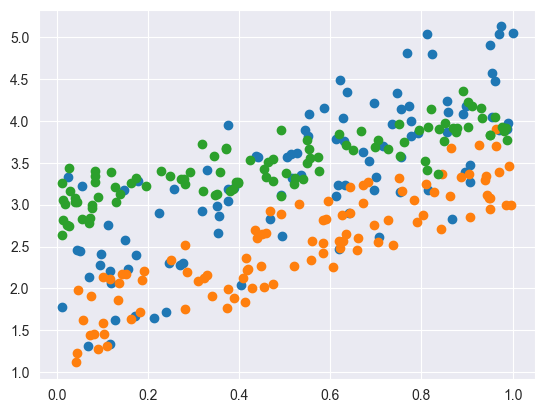

In [6]:
X_new = np.random.rand(100, 3)  # New input sample
Y_pred = X_new @ W_est + b_est

for i in range(3):
    # plt.scatter(X[:,i], Y[:,i])
    plt.scatter(X_new[:,i], Y_pred[:,i])

In [8]:
X_new[0]

array([0.05168172, 0.53135463, 0.54063512])

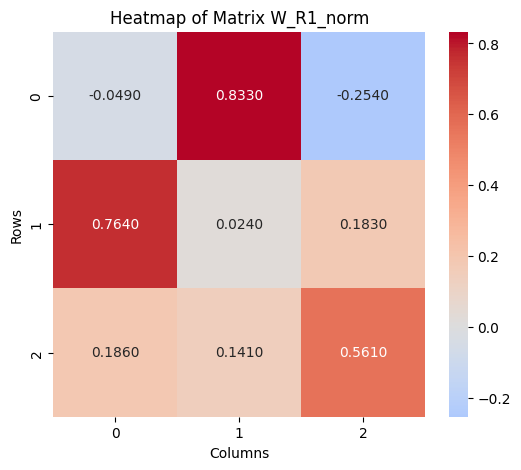

In [2]:
# Re-import necessary libraries after state reset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the new matrix W_R1_norm
W_R1_norm = np.array([
    [-0.049, 0.833, -0.254],
    [0.764,  0.024,  0.183],
    [0.186,  0.141,  0.561]
])

# Plotting the heatmap for W_R1_norm
plt.figure(figsize=(6, 5))
sns.heatmap(W_R1_norm, annot=True, cmap='coolwarm', center=0, fmt=".4f")
plt.title("Heatmap of Matrix W_R1_norm")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

## Single leg Experiment

In [11]:
def plot_heatmap(W, W_norm, title_name):
    # Define custom x and y labels
    x_labels = ['$V_x$','$V_y$','$V_z$']
    y_labels = ['$J_1$','$J_2$','$J_3$']
    # Create a 1x2 grid for subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(title_name, fontsize=24)

    # Plot heatmap for W
    sns.heatmap(W, ax=axes[0], annot=True, cmap='coolwarm', center=0, fmt=".4f", cbar=True,
                annot_kws={"size": 18}, square=True)
    axes[0].set_title("W", fontsize=22)
    axes[0].set_xticks([0.5, 1.5, 2.5])  # Set x-tick positions
    axes[0].set_xticklabels(x_labels, size=20)  # Set custom x-axis labels
    axes[0].set_yticks([0.5, 1.5, 2.5])  # Set y-tick positions
    axes[0].set_yticklabels(y_labels, rotation=0, size=20)  # Set custom y-axis labels

    # Plot heatmap for W_norm
    sns.heatmap(W_norm, ax=axes[1], annot=True, cmap='coolwarm', center=0, fmt=".4f", cbar=True,
                annot_kws={"size": 18}, square=True)
    axes[1].set_title("W_Norm", fontsize=22)
    axes[1].set_xticks([0.5, 1.5, 2.5])  # Set x-tick positions
    axes[1].set_xticklabels(x_labels, size=20)  # Set custom x-axis labels
    axes[1].set_yticks([0.5, 1.5, 2.5])  # Set y-tick positions
    axes[1].set_yticklabels(y_labels, rotation=0, size=20)  # Set custom y-axis labels

    # Increase colorbar label size
    for ax in axes:
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=16)

    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)  # To make space for the title

    # Show the plot
    plt.show()


In [11]:

def plot_heatmaps_2x2(W_R1_norm, W_R2_norm, W_L1_norm, W_L2_norm, title_name=''):
    # Define custom x and y labels
    x_labels = ['$V_x$', '$V_y$', '$V_z$']
    y_labels = ['$J_1$', '$J_2$', '$J_3$']

    # Create a 2x2 grid for subplots
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    fig.suptitle(title_name, fontsize=18)

    # Flatten the axes array for easier iteration
    axes = axes.flatten()

    # List of W_norm matrices and their corresponding titles
    W_norm_matrices = [W_R1_norm, W_L1_norm, W_R2_norm, W_L2_norm]
    titles = ['W_R1_norm', 'W_L1_norm', 'W_R2_norm', 'W_L2_norm']

    # Plot each W_norm matrix in a subplot
    for i, (W_norm, title) in enumerate(zip(W_norm_matrices, titles)):
        sns.heatmap(W_norm, ax=axes[i], annot=True, cmap='coolwarm', center=0, fmt=".4f", cbar=True,
                    annot_kws={"size": 10}, square=True, vmin=-1, vmax=1)
        axes[i].set_title(title, fontsize=12)
        axes[i].set_xticks([0.5, 1.5, 2.5])  # Set x-tick positions
        axes[i].set_xticklabels(x_labels, size='large')  # Set custom x-axis labels
        axes[i].set_yticks([0.5, 1.5, 2.5])  # Set y-tick positions
        axes[i].set_yticklabels(y_labels, rotation=0, size='large')  # Set custom y-axis labels

    # Adjust layout
    # plt.subplots_adjust(top=0.9)  # To make space for the title
    plt.tight_layout()

    # Show the plot
    plt.show()


In [12]:
def plot_heatmaps_3x2(W_R1_norm, W_R2_norm, W_R3_norm, W_L1_norm, W_L2_norm, W_L3_norm, title_name):
    # Define custom x and y labels
    x_labels = ['$V_x$', '$V_y$', '$V_z$']
    y_labels = ['$J_1$', '$J_2$', '$J_3$']

    # Create a 3x2 grid for subplots
    fig, axes = plt.subplots(3, 2, figsize=(8, 12))
    fig.suptitle(title_name, fontsize=24)

    # Flatten the axes array for easier iteration
    axes = axes.flatten()

    # List of W_norm matrices and their corresponding titles
    W_norm_matrices = [W_R1_norm, W_L1_norm, W_R2_norm, W_L2_norm, W_R3_norm, W_L3_norm]
    titles = ['W_R1_norm', 'W_L1_norm', 'W_R2_norm', 'W_L2_norm', 'W_R3_norm', 'W_L3_norm']

    # Plot each W_norm matrix in a subplot
    for i, (W_norm, title) in enumerate(zip(W_norm_matrices, titles)):
        sns.heatmap(W_norm, ax=axes[i], annot=True, cmap='coolwarm', center=0, fmt=".4f", cbar=True,
                    annot_kws={"size": 10}, square=True, vmin=-1, vmax=1)
        axes[i].set_title(title, fontsize=12)
        axes[i].set_xticks([0.5, 1.5, 2.5])  # Set x-tick positions
        axes[i].set_xticklabels(x_labels, size='large')  # Set custom x-axis labels
        axes[i].set_yticks([0.5, 1.5, 2.5])  # Set y-tick positions
        axes[i].set_yticklabels(y_labels, rotation=0, size='large')  # Set custom y-axis labels

    # Increase colorbar label size
    # for ax in axes:
    #     cbar = ax.collections[0].colorbar
    #     cbar.ax.tick_params(labelsize=16)

    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)  # To make space for the title

    # Show the plot
    plt.show()

### HEXA config

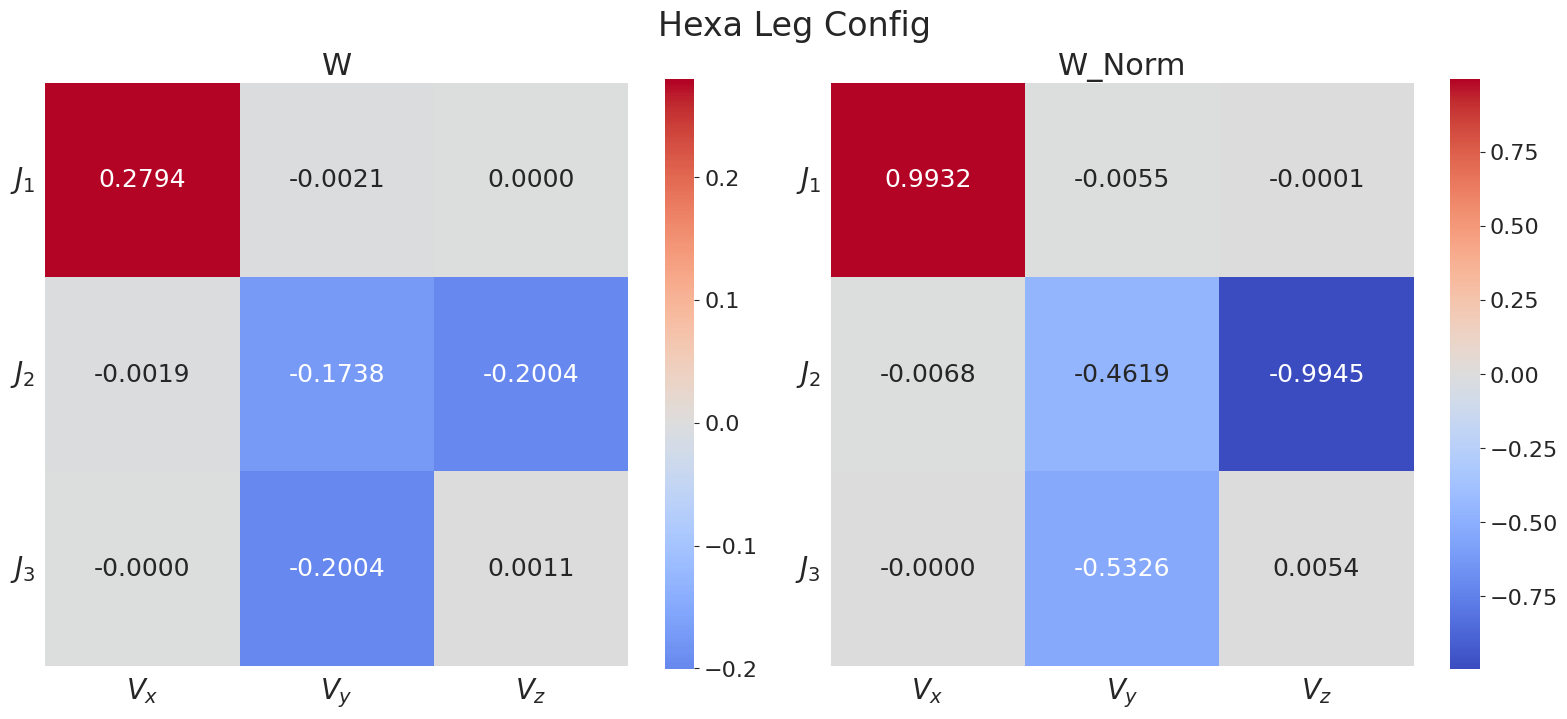

In [16]:
# 1 leg
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Defining the given matrix
W = np.array([[-0.2794, 0.0021, 0.0000],
              [0.0019, 0.1738, -0.2004],
              [0.0000, 0.2004, 0.0011]])

W_norm = np.array([[-0.9932, 0.0055, -0.0001],
                   [0.0068, 0.4619, -0.9945],
                   [0.0000, 0.5326, 0.0054]])

# For paper values
# Multiply first 2 columns with -1 for both W and W_norm
W[:, :2] *= -1
W_norm[:, :2] *= -1

plot_heatmap(W, W_norm, 'Hexa Leg Config')

### DB Leg Config

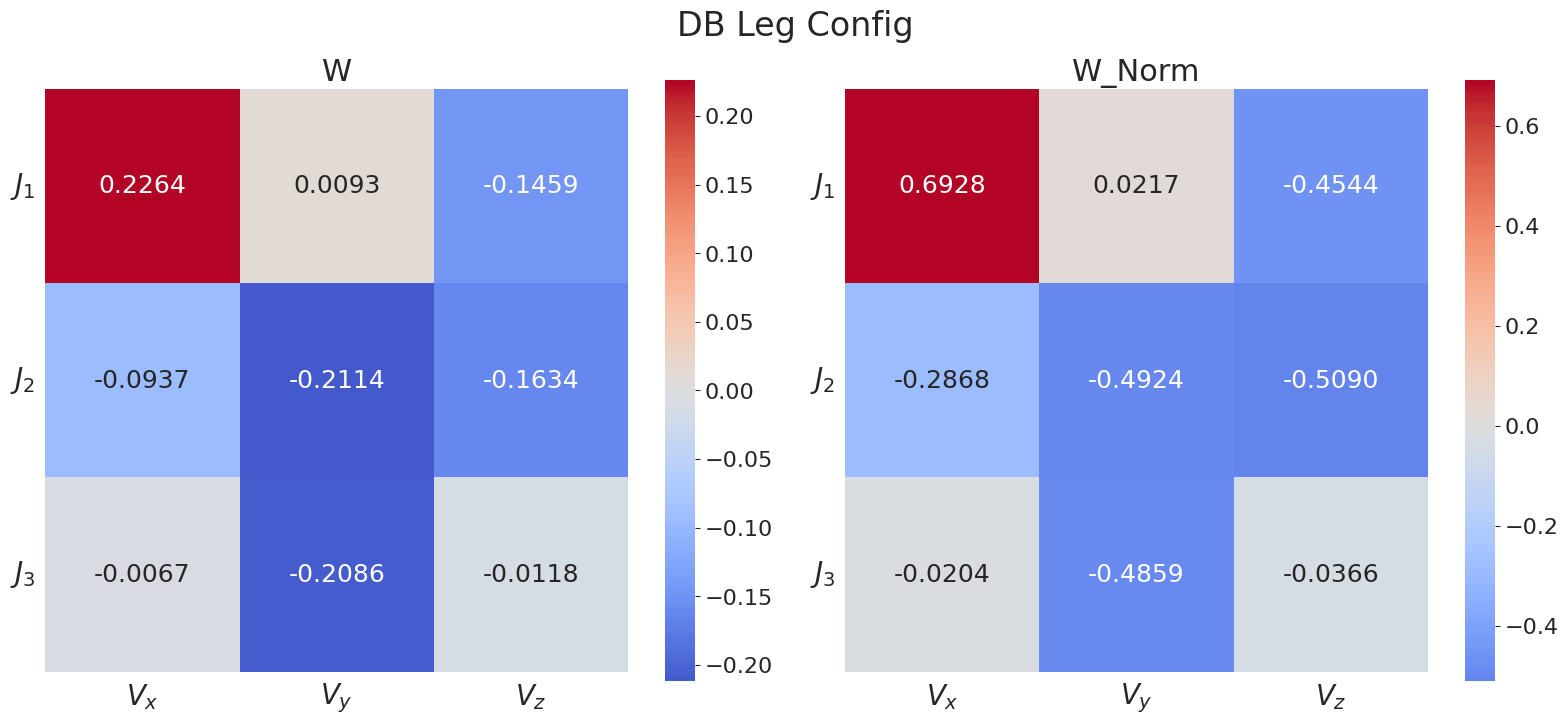

In [17]:
# 1 leg
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Defining the given matrix
W = np.array([
    [-0.2264, -0.0093, -0.1459],
    [0.0937, 0.2114, -0.1634],
    [0.0067, 0.2086, -0.0118]
])
W_norm = np.array([
    [-0.6928, -0.0217, -0.4544],
    [0.2868, 0.4924, -0.5090],
    [0.0204, 0.4859, -0.0366]
])
# For paper values
# Multiply first 2 columns with -1 for both W and W_norm
W[:, :2] *= -1
W_norm[:, :2] *= -1

plot_heatmap(W, W_norm, 'DB Leg Config')

### Quadruped Leg config

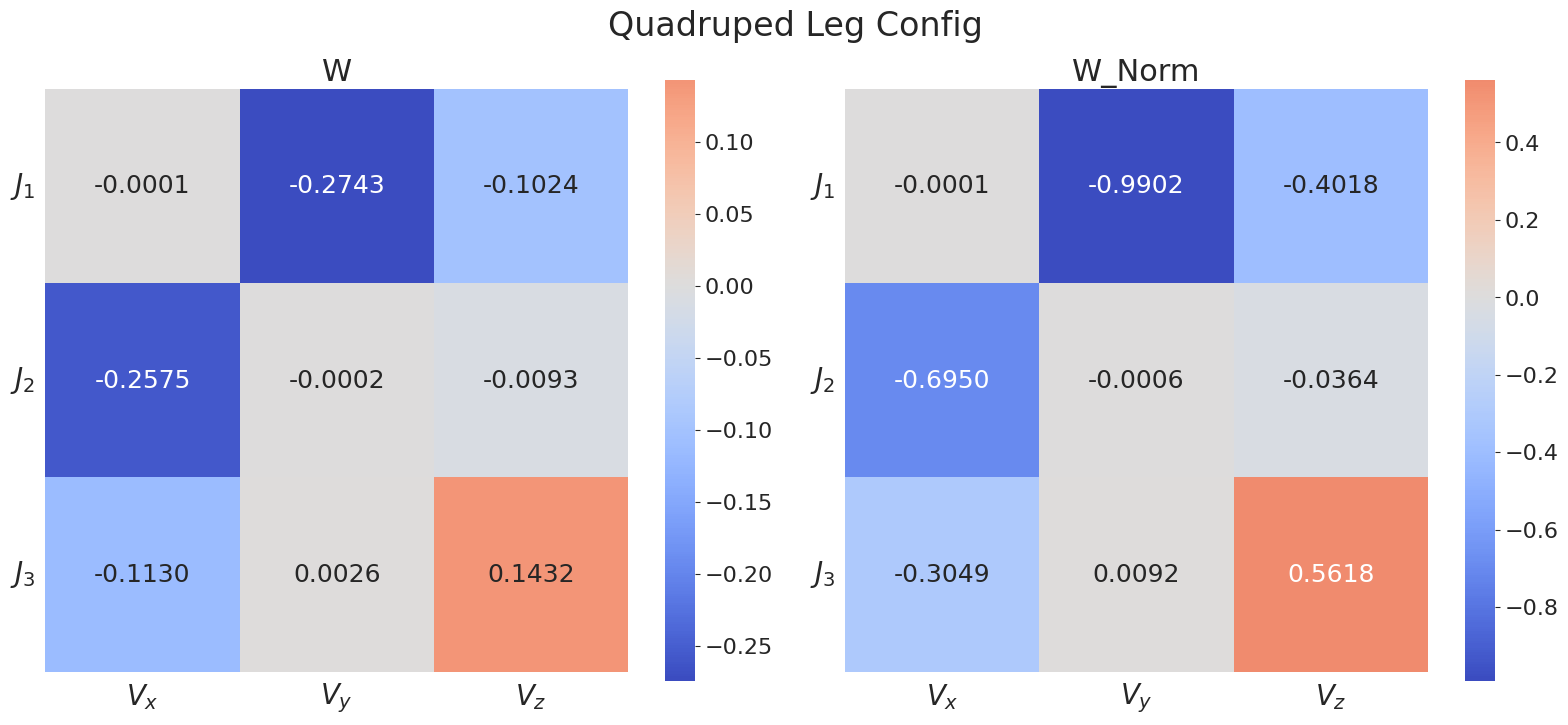

In [18]:
# 1 leg
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Defining the given matrix
W = np.array([
    [0.0001, 0.2743, -0.1024],  # First row corresponds to W[1][1], W[1][2], W[1][3]
    [0.2575, 0.0002, -0.0093],  # Second row corresponds to W[2][1], W[2][2], W[2][3]
    [0.1130, -0.0026, 0.1432]   # Third row corresponds to W[3][1], W[3][2], W[3][3]
])

W_norm = np.array([
    [0.0001, 0.9902, -0.4018],  # First row corresponds to W_norm[1][1], W_norm[1][2], W_norm[1][3]
    [0.6950, 0.0006, -0.0364],  # Second row corresponds to W_norm[2][1], W_norm[2][2], W_norm[2][3]
    [0.3049, -0.0092, 0.5618]   # Third row corresponds to W_norm[3][1], W_norm[3][2], W_norm[3][3]
])
# For paper values
# Multiply first 2 columns with -1 for both W and W_norm
W[:, :2] *= -1
W_norm[:, :2] *= -1

plot_heatmap(W, W_norm, 'Quadruped Leg Config')

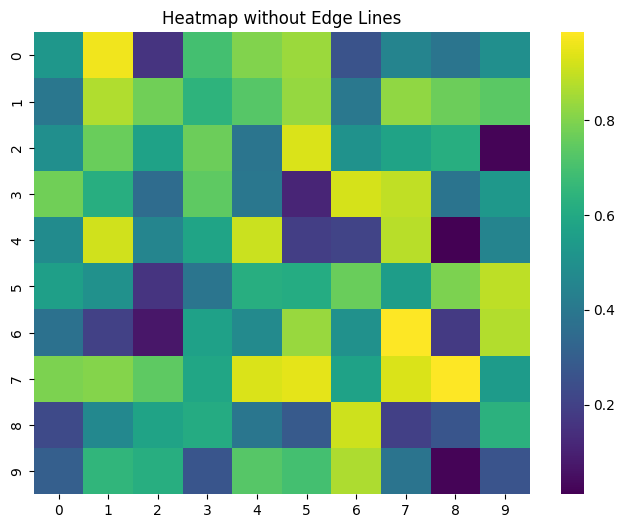

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a sample dataset
data = np.random.rand(10, 10)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data, cmap='hsv', linewidths=0)  # Set linewidths to 0 to remove edge lines
plt.title('Heatmap without Edge Lines')
plt.show()

## Vertical weight

          joint_torque_1  joint_torque_2  joint_torque_3  w_1  w_2  w_3
Time (s)                                                               
3.48                -0.0           0.941             0.0 -0.0  1.0  0.0
3.50                -0.0           0.941             0.0 -0.0  1.0  0.0
3.52                -0.0           0.941             0.0 -0.0  1.0  0.0
3.54                -0.0           0.941             0.0 -0.0  1.0  0.0
3.56                -0.0           0.941             0.0 -0.0  1.0  0.0


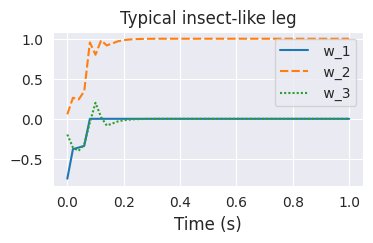

Extracted values: [-0.  1.  0.]


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # Ensure seaborn is imported

# Specify the path to your .txt file
file_path = 'data/vertical_hex.txt'

# Load the data
df = pd.read_csv(file_path, sep=',')

# Set the 'Time (s)' column as the index
df = df.set_index('Time (s)')

# Check the last few rows to confirm the structure
print(df.tail())

# Filter the DataFrame for index range (0 to 1 seconds)
filtered_df = df[(df.index >= 0) & (df.index <= 1)]

# Select the last 50 rows of the filtered DataFrame and the last 3 columns
data = filtered_df.iloc[:, -3:]  # Adjust indices if column positions change

# Create a line plot for the selected data
plt.figure(figsize=(4, 2))
sns.lineplot(data=data)  # `data` contains the last 3 columns for plotting
plt.title('Typical insect-like leg')
plt.xlabel('Time (s)', size='large')
plt.xticks(size='medium')
plt.yticks(size='medium')
# plt.legend(['$w_{1,z}$', '$w_{2,z}$', '$w_{3,z}$'], loc='upper right')
plt.savefig('fig/hexapod_leg_config.png', dpi=300, bbox_inches='tight')
plt.show()

# Extract the last row of the last 3 columns for further use
w_h_hex = df.iloc[-1, -3:].values
print("Extracted values:", w_h_hex)

          joint_torque_1  joint_torque_2  joint_torque_3    w_1    w_2  w_3
Time (s)                                                                   
2.56               0.837           1.027             0.0  0.449  0.551  0.0
2.58               0.837           1.027             0.0  0.449  0.551  0.0
2.60               0.837           1.027             0.0  0.449  0.551  0.0
2.62               0.837           1.027             0.0  0.449  0.551  0.0
2.64               0.837           1.027             0.0  0.449  0.551  0.0


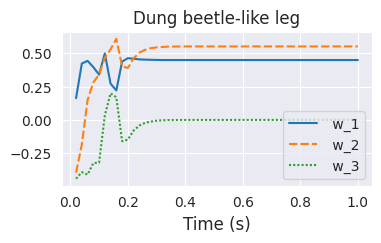

[0.449 0.551 0.   ]


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # Ensure seaborn is imported

# Specify the path to your .txt file
file_path = 'data/vertical_db.txt'  # Updated to 'vertical_db'

# Load the data
df = pd.read_csv(file_path, sep=',')

# Set the 'Time (s)' column as the index
df = df.set_index('Time (s)')

# Check the last few rows to confirm the structure
print(df.tail())

# Filter the DataFrame for index range (0 to 1 seconds)
filtered_df = df[(df.index >= 0) & (df.index <= 1)]

# Select the last 50 rows of the filtered DataFrame and the last 3 columns
data = filtered_df.iloc[-50:, -3:]  # Adjust indices as necessary

# Create a line plot for the selected data
plt.figure(figsize=(4, 2))
sns.lineplot(data=data)  # `data` contains the last 3 columns for plotting
plt.title('Dung beetle-like leg')
plt.xlabel('Time (s)', size='large')
plt.xticks(size='medium')
plt.yticks(size='medium')
plt.savefig('fig/db_leg_config.png', dpi=300, bbox_inches='tight')
plt.show()

# Extract the last row of the last 3 columns for further use
w_h_db = df.iloc[-1, -3:].values
print(w_h_db)

          joint_torque_1  joint_torque_2  joint_torque_3    w_1    w_2   w_3
Time (s)                                                                    
3.52               0.036          -0.017          -0.083  0.267 -0.123 -0.61
3.54               0.036          -0.017          -0.083  0.267 -0.123 -0.61
3.56               0.036          -0.017          -0.083  0.267 -0.123 -0.61
3.58               0.036          -0.017          -0.083  0.267 -0.123 -0.61
3.60               0.036          -0.017          -0.083  0.267 -0.123 -0.61


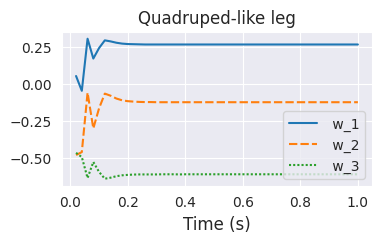

Extracted values: [ 0.267 -0.123 -0.61 ]


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # Ensure seaborn is imported

# Specify the path to your .txt file
file_path = 'data/vertical_quad.txt'

# Load the data
df = pd.read_csv(file_path, sep=',')

# Set the 'Time (s)' column as the index
df = df.set_index('Time (s)')

# Check the last few rows to confirm the structure
print(df.tail())

# Filter the DataFrame for index range (0 to 1 seconds)
filtered_df = df[(df.index >= 0) & (df.index <= 1)]

# Select the last 50 rows of the filtered DataFrame and the last 3 columns
data = filtered_df.iloc[-50:, -3:]  # Adjust indices if column positions change

# Create a line plot for the selected data
plt.figure(figsize=(4, 2))
sns.lineplot(data=data)  # `data` contains the last 3 columns for plotting
plt.title('Quadruped-like leg')
plt.xlabel('Time (s)', size='large')
plt.xticks(size='medium')
plt.yticks(size='medium')
plt.savefig('fig/quad_leg_config.png', dpi=300, bbox_inches='tight')
plt.show()

# Extract the last row of the last 3 columns for further use
w_h_quad = df.iloc[-1, -3:].values
print("Extracted values:", w_h_quad)


In [74]:
ls data

hor_1leg_hex.csv  vertical_db.txt  vertical_hex.txt  vertical_quad.txt


## Horizontal weights

### Hex

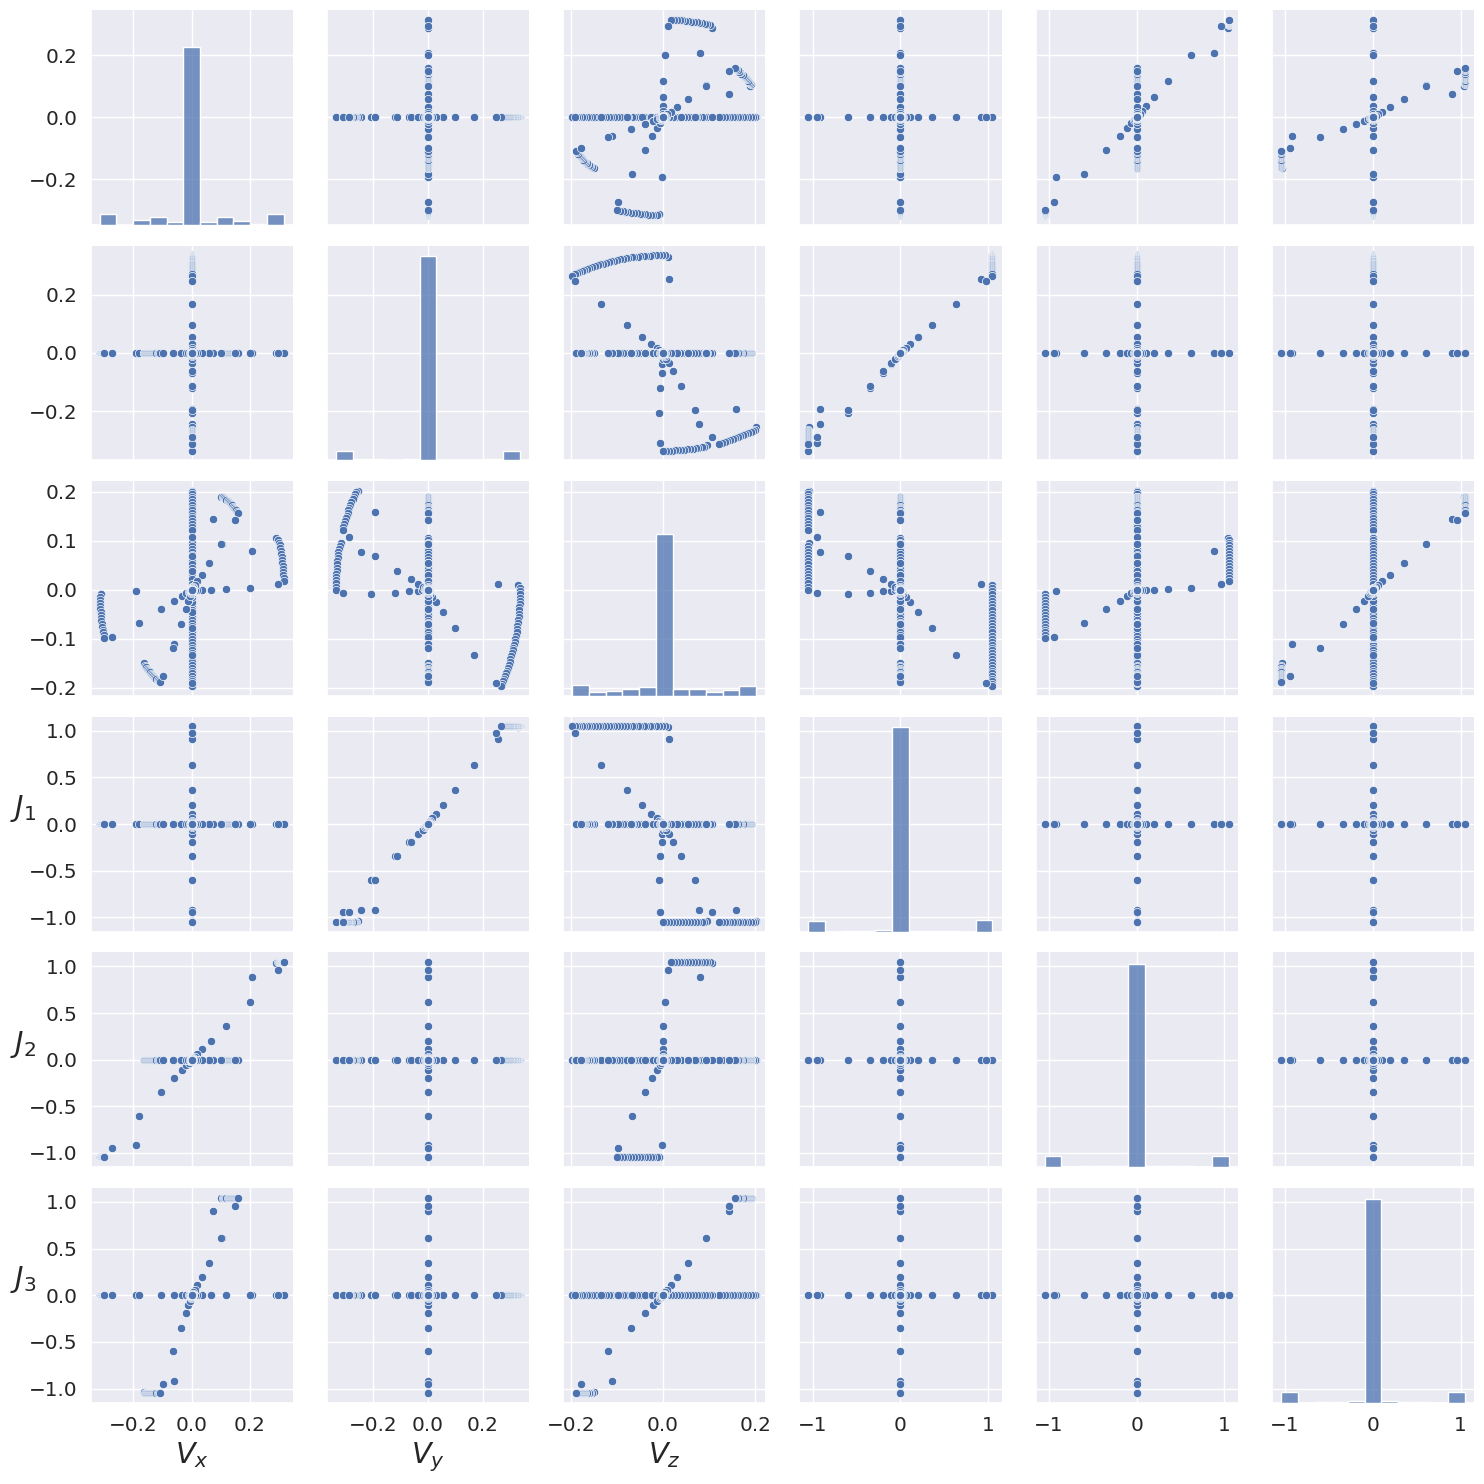

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # Ensure seaborn is imported

# Specify the path to your .txt file
# file_path = 'data/hor_1leg_hex.csv'
# file_path = 'data/hor_1leg_db.csv'
file_path = 'data/hor_1leg_quad.csv'

# Load the data
df = pd.read_csv(file_path, sep=',')

# Set the 'Time (s)' column as the index
df = df.set_index('Time (s)')
df = df[df.columns[-3:].tolist() + df.columns[:-3].tolist()]

# Filter out rows where Joint Vel 1, Joint Vel 2, and Joint Vel 3 are all zero
# filtered_df = df[((abs(df["Joint Vel 1"]) > 0.3) | (abs(df["Joint Vel 2"]) > 0.3) | (abs(df["Joint Vel 3"]) > 0.3))]
sns.set(font_scale = 1)
pairplot = sns.pairplot(df)

# Modify the x and y labels
x_labels = ['$V_x$', '$V_y$', '$V_z$', '', '', '']  # Replace with your desired x-axis labels
y_labels = ['', '', '', '$J_1$', '$J_2$', '$J_3$']  # Replace with your desired y-axis labels

# Loop through the axes and set the labels with fontsize='xx-large'
for i in range(len(df.columns)):
    for j in range(len(df.columns)):
        # Set x-axis labels for the bottom row
        if i == len(df.columns) - 1:
            pairplot.axes[i, j].set_xlabel(x_labels[j], fontsize='xx-large')
            pairplot.axes[i, j].tick_params(axis='x', labelsize='large')  # Set xtick label size
        # Set y-axis labels for the first column
        if j == 0:
            pairplot.axes[i, j].set_ylabel(y_labels[i], fontsize='xx-large', rotation=0)
            pairplot.axes[i, j].tick_params(axis='y', labelsize='large')  # Set xtick label size

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

<Axes: xlabel='Time (s)'>

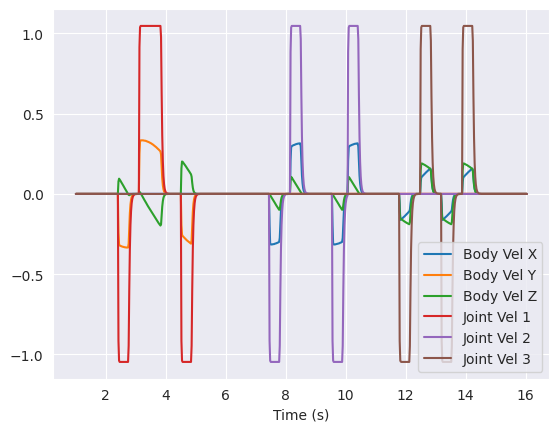

In [231]:
df.plot()

### Weight matrix

In [232]:
w_h_hex, w_h_db, w_h_quad

(array([-0.,  1.,  0.]),
 array([0.445, 0.555, 0.   ]),
 array([ 0.267, -0.123, -0.61 ]))

In [ ]:
W_norm_hex = np.array([[-0.998854, 0.078897, 0.000009], 
              [0.001058, 0.436582, -0.999967], 
              [-0.000088, 0.484521, -0.000024]])
W_norm_db  = np.array([[-0.713957, -0.026524, -0.452033], 
              [ 0.28165, 0.472353, -0.539437], 
              [-0.004393, 0.501123, 0.00853]])
W_norm_quad = np.array([[-0.000003, 0.999948, -0.461813], 
               [0.646197, -0.000002, -0.065033], 
               [0.353801, -0.000051, 0.473154]])

W_hex = np.array([
    [-0.2264, -0.0093, -0.1459],
    [0.0937, 0.2114, -0.1634],
    [0.0067, 0.2086, -0.0118]
])
W_db = np.array([
    [-0.2264, -0.0093, -0.1459],
    [0.0937, 0.2114, -0.1634],
    [0.0067, 0.2086, -0.0118]
])
W_quad = np.array([
    [0.0001, 0.2743, -0.1024],  # First row corresponds to W[1][1], W[1][2], W[1][3]
    [0.2575, 0.0002, -0.0093],  # Second row corresponds to W[2][1], W[2][2], W[2][3]
    [0.1130, -0.0026, 0.1432]   # Third row corresponds to W[3][1], W[3][2], W[3][3]
])


W_norm_hex

array([[-9.98854e-01,  7.88970e-02,  9.00000e-06],
       [ 1.05800e-03,  4.36582e-01, -9.99967e-01],
       [-8.80000e-05,  4.84521e-01, -2.40000e-05]])

In [240]:
W_norm_hex, W_mix_hex

(array([[-9.98854e-01,  7.88970e-02,  9.00000e-06],
        [ 1.05800e-03,  4.36582e-01, -9.99967e-01],
        [-8.80000e-05,  4.84521e-01, -2.40000e-05]]),
 array([[ 9.98854e-01, -7.88970e-02, -0.00000e+00],
        [-1.05800e-03, -4.36582e-01,  1.00000e+00],
        [ 8.80000e-05, -4.84521e-01,  0.00000e+00]]))

In [236]:
W_mix_hex = np.copy(W_norm_hex)*-1
W_mix_db  = np.copy(W_norm_db)*-1
W_mix_quad= np.copy(W_norm_quad)*-1
W_mix_hex[:,2] = w_h_hex
W_mix_db[:,2] = w_h_db
W_mix_quad[:,2] = w_h_quad

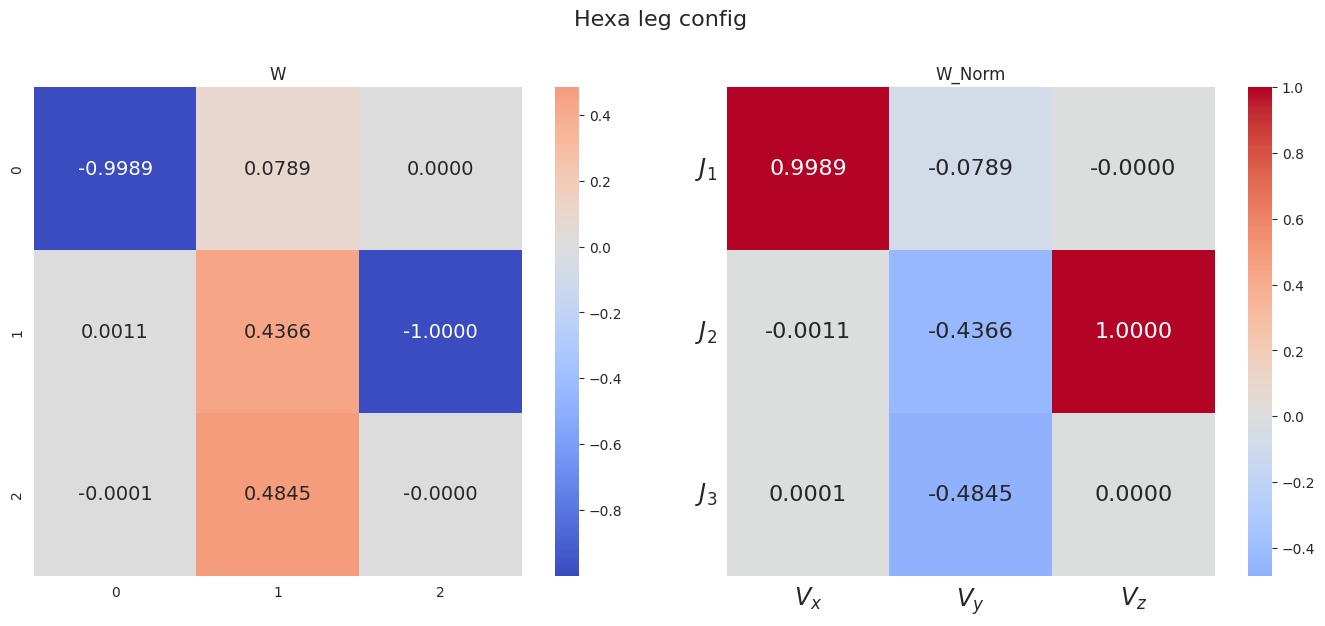

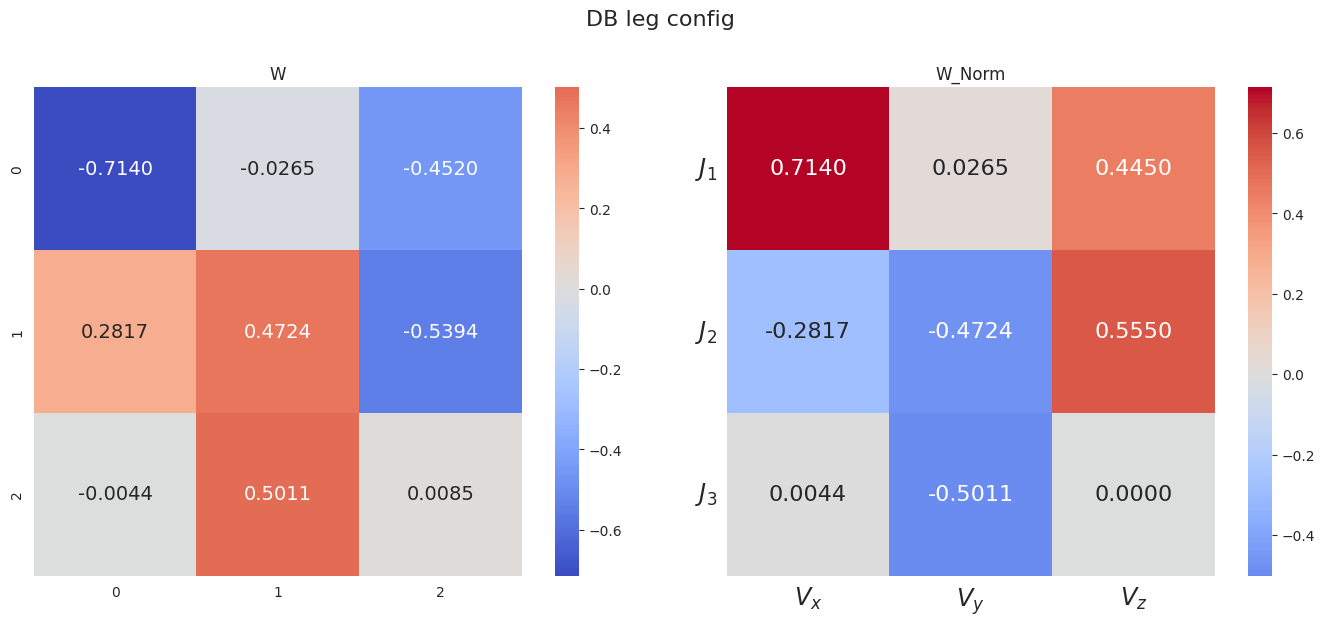

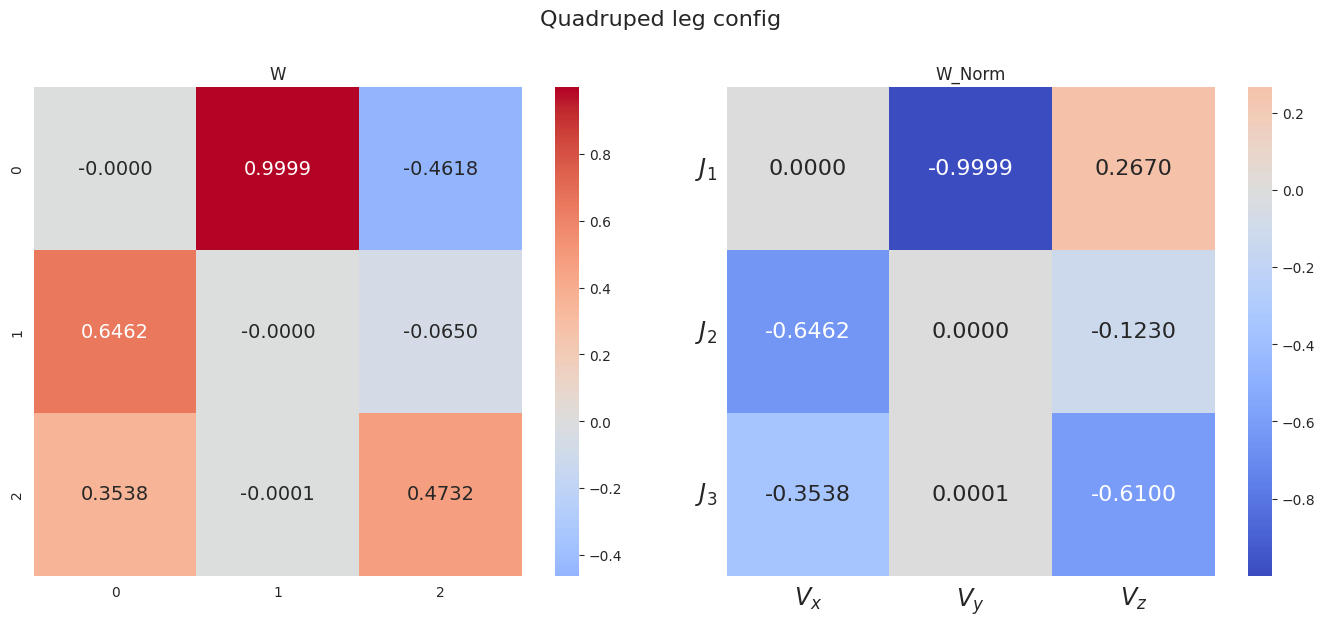

In [248]:
plot_heatmap(W_norm_hex, W_mix_hex, 'Hexa leg config')
plot_heatmap(W_norm_db, W_mix_db, 'DB leg config')
plot_heatmap(W_norm_quad, W_mix_quad, 'Quadruped leg config')

## Multiple Legs experiment

## Vertical Weight

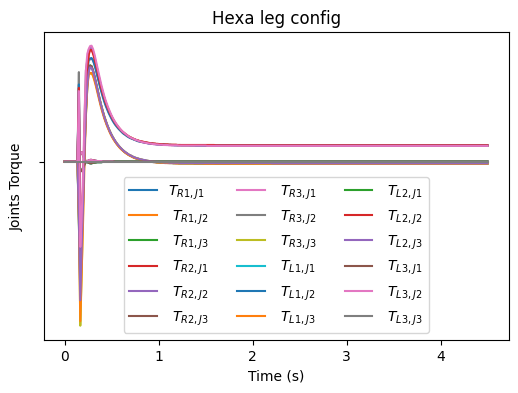

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # Ensure seaborn is imported

# Specify the path to your .txt file
file_path = 'data/vertical_hex_6legs.txt'
# file_path = 'data/hor_1leg_db.csv'
# file_path = 'data/hor_1leg_quad.csv'

# Load the data
df = pd.read_csv(file_path, sep=',', index_col='Time (s)')
df

# Function to transform column names
def transform_column_name(name):
    # Replace 'torque_' with '$T_{' and add '}$' at the end
    name = name.replace('torque_', '$T_{') + '}$'
    # Find the index of the last underscore
    last_underscore_index = name.rfind('_')
    # Replace the last underscore with a comma
    if last_underscore_index != -1:  # Ensure an underscore exists
        name = name[:last_underscore_index] + ',' + name[last_underscore_index + 1:]
    # Add '}$' at the end
    return name

# Apply the transformation to column names
df.columns = [transform_column_name(col) for col in df.columns]

# Set 'Time (s)' as the x-axis
x = df.index

# Plot all other columns against 'Time (s)'
plt.figure(figsize=(6, 4))
for column in df.columns[0:]:  # Skip the first column ('Time (s)')
    plt.plot(x, df[column], label=column)
# Set the legend with 3 columns
plt.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5,0.55))
plt.xlabel('Time (s)')
plt.ylabel('Joints Torque')
# Set the 'Time (s)' column as the index
# df = df.set_index('Time (s)')


# Filter the DataFrame for index range (0 to 1 seconds)
# filtered_df = df[(df.index >= 0) & (df.index <= 2)]

# Create a line plot for the selected data
# plt.figure(figsize=(4, 2))
# plt.plot(df)  # `data` contains the last 3 columns for plotting
plt.title('Hexa leg config')
# # plt.legend(False)
plt.show()

In [20]:
# Rename columns: replace 'torque' with '$T$'
df.columns = df.columns.str.replace('torque', 'T')
df

,T_R1_J1,T_R1_J2,T_R1_J3,T_R2_J1,T_R2_J2,T_R2_J3,T_R3_J1,T_R3_J2,T_R3_J3,T_L1_J1,T_L1_J2,T_L1_J3,T_L2_J1,T_L2_J2,T_L2_J3,T_L3_J1,T_L3_J2,T_L3_J3
Time (s),,,,,,,,,,,,,,,,,,
0.000,-0.0,-0.000,-0.000,-0.0,-0.000,-0.000,-0.0,-0.000,-0.000,0.0,-0.000,0.000,0.0,-0.000,-0.000,0.0,-0.000,
0.000,-0.0,-0.000,-0.000,-0.0,-0.000,-0.000,-0.0,-0.000,-0.000,0.0,-0.000,0.000,0.0,-0.000,-0.000,0.0,-0.000,
0.000,-0.0,-0.000,-0.000,-0.0,-0.000,-0.000,-0.0,-0.000,-0.000,0.0,-0.000,0.000,0.0,-0.000,-0.000,0.0,-0.000,
0.015,-0.0,-0.000,-0.000,-0.0,-0.000,-0.000,0.0,-0.000,-0.000,0.0,-0.000,-0.000,-0.0,-0.000,-0.000,-0.0,-0.000,
0.015,-0.0,-0.000,-0.000,-0.0,-0.000,-0.000,0.0,-0.000,-0.000,0.0,-0.000,-0.000,-0.0,-0.000,-0.000,-0.0,-0.000,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4.485,-0.0,0.056,-0.007,0.0,0.056,-0.006,-0.0,0.056,-0.007,0.0,0.056,-0.007,-0.0,0.057,-0.006,0.0,0.055,
4.485,-0.0,0.056,-0.007,0.0,0.056,-0.006,-0.0,0.056,-0.007,0.0,0.056,-0.007,-0.0,0.057,-0.006,0.0,0.055,
4.500,-0.0,0.056,-0.007,0.0,0.056,-0.006,-0.0,0.056,-0.007,0.0,0.056,-0.007,-0.0,0.057,-0.006,0.0,0.055,


<Axes: xlabel='Time (s)'>

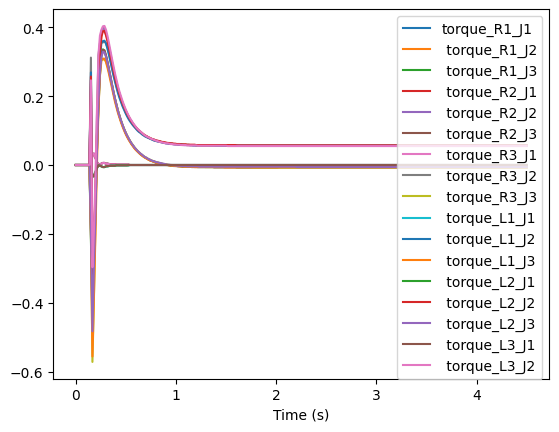

In [6]:
w_h_R1_hex = [-0.0025, 0.9924, -0.1229]
w_h_R2_hex = [0.0015, 0.9934, -0.1145]
w_h_R3_hex = [-0.0027, 0.9917, -0.1289]
w_h_L1_hex = [0.0024, 0.9923, -0.1242]
w_h_L2_hex = [-0.0017, 0.9949, -0.1004]
w_h_L3_hex = [0.0029, 0.9898, -0.1427]

### Hexapod 4 leg

In [13]:
# Define the matrices
W_R1_norm_hex = np.array([[-0.799712, -0.157347, -0.043959],
                      [0.119974, 0.473843, -0.92391],
                      [-0.080314, 0.36881, 0.032131]])

W_R2_norm_hex = np.array([[-0.761465, 0.007147, -0.028748],
                      [-0.10626, 0.415506, -0.779834],
                      [0.132275, 0.577347, 0.191418]])

W_L1_norm_hex = np.array([[-0.77013, 0.022117, 0.066064],
                      [0.025808, -0.459398, -0.743948],
                      [-0.204062, -0.518485, 0.189988]])

W_L2_norm_hex = np.array([[-0.712486, -0.100218, -0.367934],
                      [-0.076179, -0.347773, -0.566821],
                      [0.211334, -0.55201, 0.065246]])

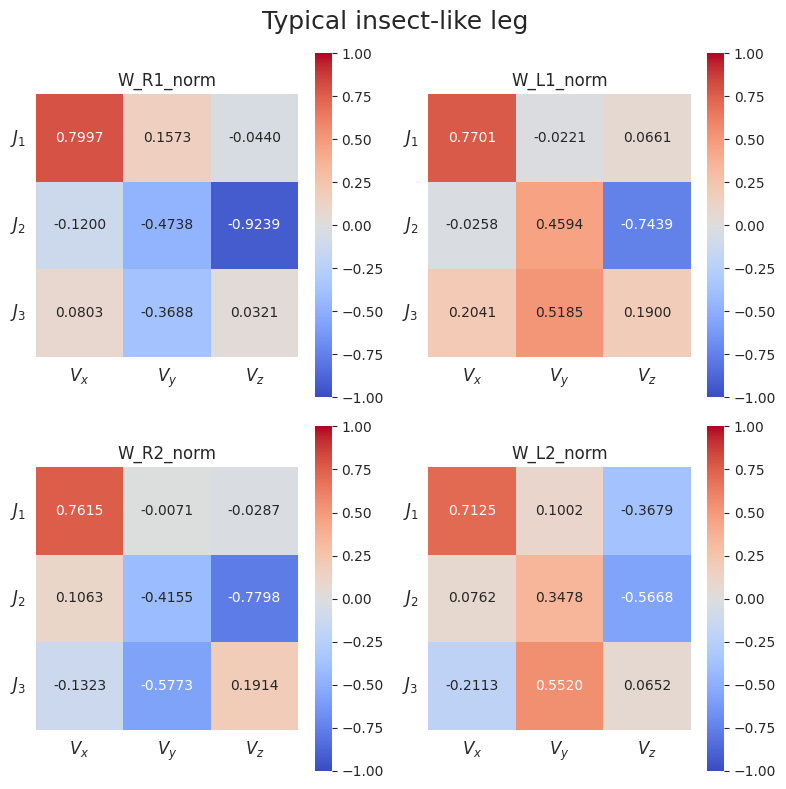

In [14]:
# Multiply first 2 columns with -1 for both W and W_norm
def plot_heatmaps_fullbody(W_R1_norm, W_R2_norm, W_L1_norm, W_L2_norm):
    W_R1_norm_hex[:, :2] *= -1
    W_R2_norm_hex[:, :2] *= -1
    W_L1_norm_hex[:, :2] *= -1
    W_L2_norm_hex[:, :2] *= -1
    plot_heatmaps_2x2(W_R1_norm_hex, W_R2_norm_hex, W_L1_norm_hex, W_L2_norm_hex, 'Typical insect-like leg')

plot_heatmaps_fullbody(W_R1_norm_hex, W_R2_norm_hex, W_L1_norm_hex, W_L2_norm_hex)


### Dung beetle-like leg config

In [64]:
W_R1_norm_db = np.array([
    [-0.6769, -0.0837, 0.1674],  # Row 1
    [0.3093, 0.5022, 0.4233],    # Row 2
    [-0.0139, 0.4141, -0.4092]   # Row 3
])
W_R2_norm_db = np.array([
    [-0.7237, 0.0043, -0.1674],  # Row 1
    [-0.2452, 0.3879, 0.4233],   # Row 2
    [-0.0311, 0.6078, -0.4093]   # Row 3
])
W_L1_norm_db = np.array([
    [-0.5026, -0.1400, 0.1675],  # Row 1
    [0.2492, -0.3744, 0.4232],   # Row 2
    [-0.2482, -0.4856, -0.4093]  # Row 3
])
W_L2_norm_db = np.array([
    [-0.4716, -0.0286, -0.1675],  # Row 1
    [-0.2027, -0.3703, 0.4233],   # Row 2
    [0.3256, -0.6011, -0.4092]    # Row 3
])

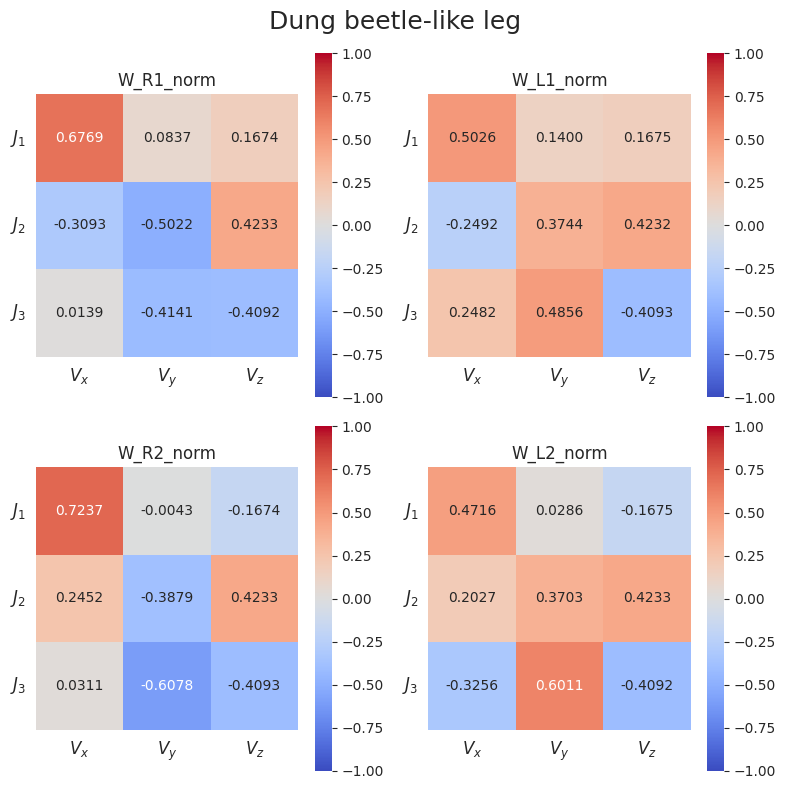

In [65]:
# Multiply first 2 columns with -1 for both W and W_norm
def plot_heatmaps_fullbody(W_R1_norm, W_R2_norm, W_L1_norm, W_L2_norm):
    W_R1_norm_db[:, :2] *= -1
    W_R2_norm_db[:, :2] *= -1
    W_L1_norm_db[:, :2] *= -1
    W_L2_norm_db[:, :2] *= -1
    plot_heatmaps_2x2(W_R1_norm_db, W_R2_norm_db, W_L1_norm_db, W_L2_norm_db, 'Dung beetle-like leg')

plot_heatmaps_fullbody(W_R1_norm_db, W_R2_norm_db, W_L1_norm_db, W_L2_norm_db)


### Quadrped

In [66]:
W_R1_norm_quad = np.array([
    [-0.1209,  0.8373,  0.1599],  # (e_sw, e_sd, e_st)
    [ 0.6813, -0.0163, -0.2130],
    [ 0.1978,  0.1464, -0.6271]
])

W_R2_norm_quad = np.array([
    [ 0.1593,  0.6560,  0.1669],  # (e_sw, e_sd, e_st)
    [ 0.4864, -0.1607, -0.2109],
    [ 0.3542,  0.1833, -0.6222]
])

W_L1_norm_quad = np.array([
    [-0.0612, -0.8584,  0.1604],  # (e_sw, e_sd, e_st)
    [ 0.7494, -0.0427, -0.2154],
    [ 0.1895, -0.0988, -0.6241]
])

W_L2_norm_quad = np.array([
    [ 0.0157, -0.5912,  0.1657],  # (e_sw, e_sd, e_st)
    [ 0.5158,  0.2118, -0.2105],
    [ 0.4685, -0.1970, -0.6238]
])


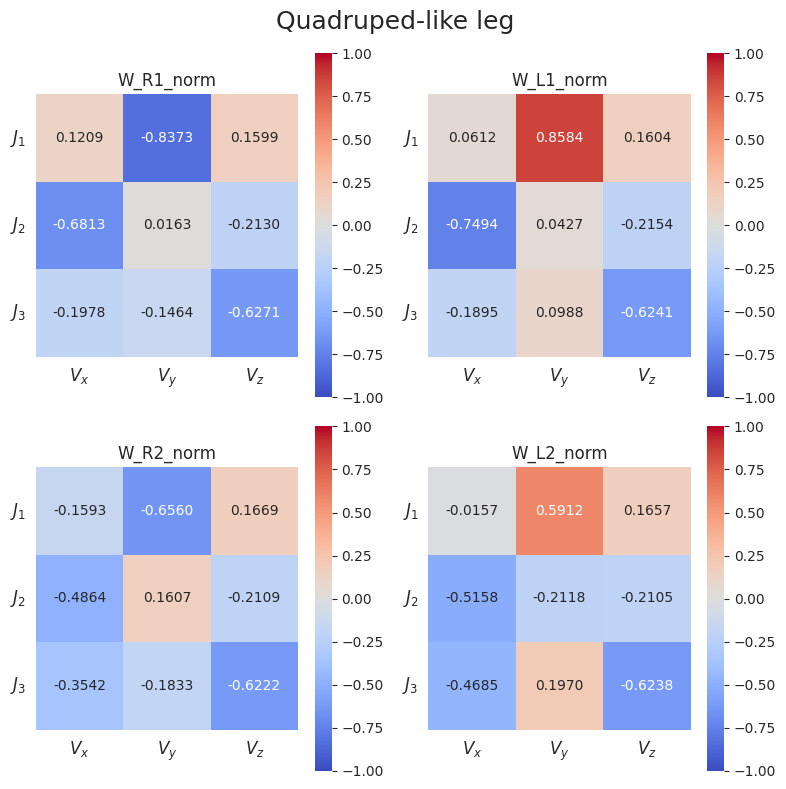

In [67]:
# Multiply first 2 columns with -1 for both W and W_norm
def plot_heatmaps_fullbody(W_R1_norm, W_R2_norm, W_L1_norm, W_L2_norm):
    W_R1_norm_quad[:, :2] *= -1
    W_R2_norm_quad[:, :2] *= -1
    W_L1_norm_quad[:, :2] *= -1
    W_L2_norm_quad[:, :2] *= -1
    plot_heatmaps_2x2(W_R1_norm_quad, W_R2_norm_quad, W_L1_norm_quad, W_L2_norm_quad, 'Quadruped-like leg')

plot_heatmaps_fullbody(W_R1_norm_quad, W_R2_norm_quad, W_L1_norm_quad, W_L2_norm_quad)


### Hex 6 legs

In [68]:
W_R1_norm_hex6 = np.array([
    [-0.6925, -0.0794,  0.0016],  # (e_sw, e_sd, e_st)
    [ 0.1676,  0.4571,  0.5109],
    [-0.1398,  0.4635, -0.4875]
])

W_R2_norm_hex6 = np.array([
    [-0.6859,  0.0039,  0.0016],  # (e_sw, e_sd, e_st)
    [ 0.0047,  0.3971,  0.5109],
    [-0.3094,  0.5991, -0.4875]
])

W_R3_norm_hex6 = np.array([
    [-0.6107,  0.0254,  0.0016],  # (e_sw, e_sd, e_st)
    [-0.2641,  0.4281,  0.5109],
    [ 0.1252,  0.5465, -0.4875]
])

W_L1_norm_hex6 = np.array([
    [-0.6686, -0.0899, -0.0005],  # (e_sw, e_sd, e_st)
    [-0.0674, -0.4812,  0.5115],
    [-0.2640, -0.4289, -0.4880]
])

W_L2_norm_hex6 = np.array([
    [-0.8833,  0.0297, -0.0005],  # (e_sw, e_sd, e_st)
    [-0.1098, -0.3925,  0.5114],
    [-0.0069, -0.5778, -0.4880]
])

W_L3_norm_hex6 = np.array([
    [-0.6424, -0.1175, -0.0005],  # (e_sw, e_sd, e_st)
    [-0.0061, -0.3653,  0.5114],
    [ 0.3515, -0.5172, -0.4881]
])

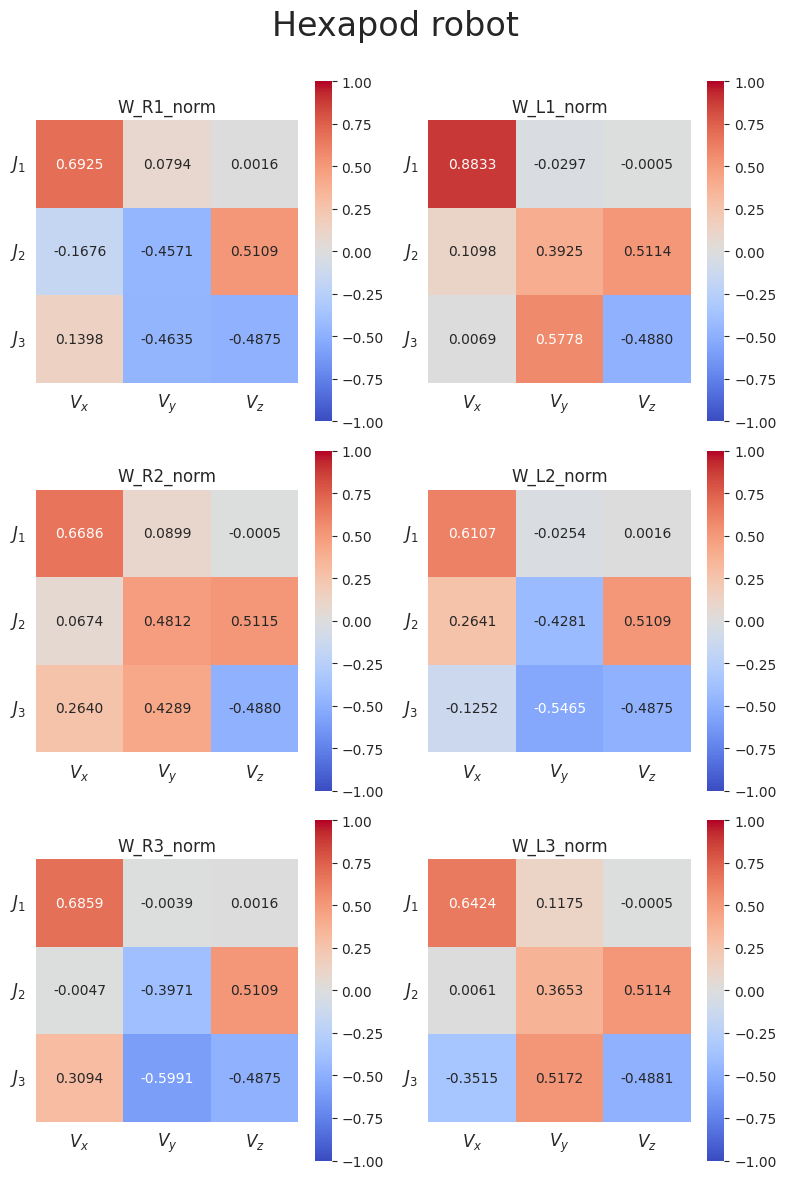

In [69]:
# Multiply first 2 columns with -1 for both W and W_norm
def plot_heatmaps_fullbody(W_R1_norm_hex6, W_L1_norm_hex6, W_R2_norm_hex6, W_L2_norm_hex6, W_R3_norm_hex6, W_L3_norm_hex6):
    W_R1_norm_hex6[:, :2] *= -1
    W_R2_norm_hex6[:, :2] *= -1
    W_R3_norm_hex6[:, :2] *= -1
    W_L1_norm_hex6[:, :2] *= -1
    W_L2_norm_hex6[:, :2] *= -1
    W_L3_norm_hex6[:, :2] *= -1
    plot_heatmaps_3x2(W_R1_norm_hex6, W_L1_norm_hex6, W_R2_norm_hex6, W_L2_norm_hex6, W_R3_norm_hex6, W_L3_norm_hex6, 'Hexapod robot')

plot_heatmaps_fullbody(W_R1_norm_hex6, W_L1_norm_hex6, W_R2_norm_hex6, W_L2_norm_hex6, W_R3_norm_hex6, W_L3_norm_hex6)


## Vary gain showing vel_x, vel_y result

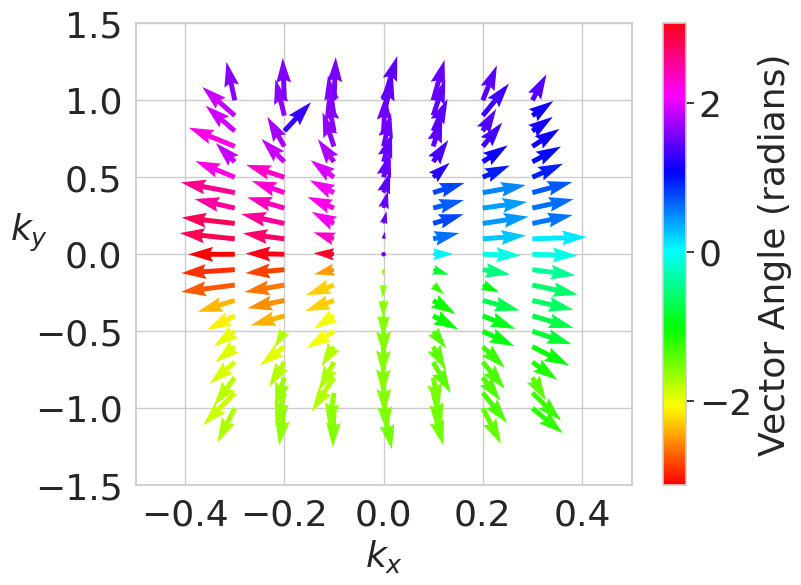

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_quiver_from_csv(file_path):
    # Load CSV file
    df = pd.read_csv(file_path)
    
    # Extract values
    k_x = df['k_x'].values
    k_y = df['k_y'].values
    final_pos_x = df['final_pos_x'].values
    final_pos_y = df['final_pos_y'].values
    
    # Compute vectors (from origin to final positions)
    u = final_pos_x  # x-component of vector
    v = final_pos_y  # y-component of vector
    
    # Compute angle of the vector (in degrees)
    angles = np.arctan2(v, u)
    
    # Create colormap based on angle
    norm = plt.Normalize(angles.min(), angles.max())
    colors = plt.cm.hsv(norm(angles))
    
    # Create the plot
    sns.set(style="whitegrid")
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Quiver plot with color
    q = ax.quiver(k_x, k_y, u, v, color=colors, angles='xy', scale_units='xy', scale=6, width=0.01)
    
    # Create colorbar
    sm = plt.cm.ScalarMappable(cmap='hsv', norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Vector Angle (radians)', fontsize=26)
    
    # Labels and title with increased size
    ax.set_xlabel('$k_x$', fontsize=26)
    # ax.set_xticklabels(ticks=[''], fontsize=18)
    # ax.set_xticks(fontsize=18)
    ax.set_ylabel('$k_y$', fontsize=26, rotation=0)
    # ax.set_title('Velocity direction', fontsize=25)
    ax.set_xlim([-0.5, 0.5])
    ax.set_ylim([-1.5, 1.5])
    plt.xticks(fontsize=26)
    plt.yticks(fontsize=26)
    cbar.ax.tick_params(labelsize=26) 

    # Show plot
    # plt.savefig('fig/hexapod_velocity_direction.png', bbox_inches='tight')
    plt.show()

# Example usage (replace 'data.csv' with your actual file path)
plot_quiver_from_csv('data_save/vary_gain_6legs.csv')


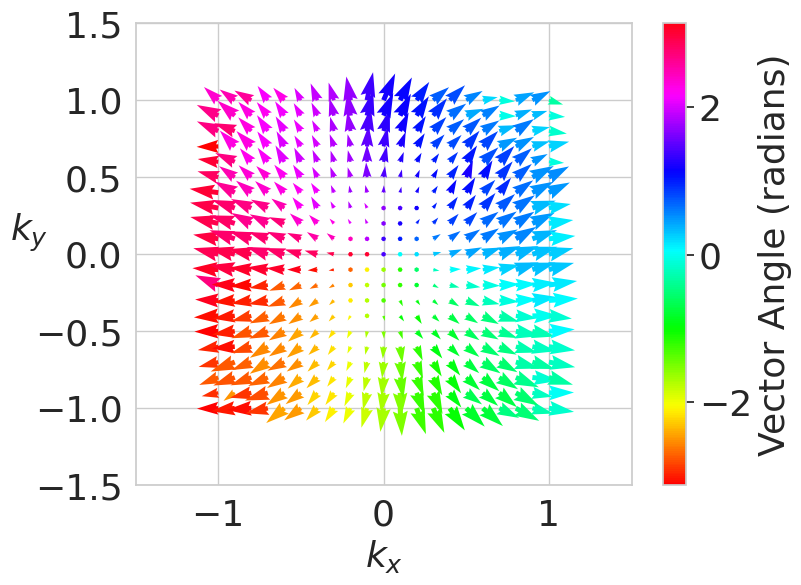

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_quiver_from_csv(file_path):
    # Load CSV file
    df = pd.read_csv(file_path)
    
    # Extract values
    k_x = df['k_x'].values
    k_y = df['k_y'].values
    final_pos_x = df['final_pos_x'].values
    final_pos_y = df['final_pos_y'].values
    
    # Compute vectors (from origin to final positions)
    u = final_pos_x  # x-component of vector
    v = final_pos_y  # y-component of vector
    
    # Compute angle of the vector (in degrees)
    angles = np.arctan2(v, u)
    
    # Create colormap based on angle
    norm = plt.Normalize(angles.min(), angles.max())
    colors = plt.cm.hsv(norm(angles))
    
    # Create the plot
    sns.set(style="whitegrid")
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Quiver plot with color
    q = ax.quiver(k_x, k_y, u, v, color=colors, angles='xy', scale_units='xy', scale=10, width=0.01)
    
    # Create colorbar
    sm = plt.cm.ScalarMappable(cmap='hsv', norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Vector Angle (radians)', fontsize=26)
    
    # Labels and title with increased size
    ax.set_xlabel('$k_x$', fontsize=26)
    # ax.set_xticklabels(ticks=[''], fontsize=18)
    # ax.set_xticks(fontsize=18)
    ax.set_ylabel('$k_y$', fontsize=26, rotation=0)
    # ax.set_title('Velocity direction', fontsize=25)
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    plt.xticks([-1, 0, 1], fontsize=26)
    plt.yticks(fontsize=26)
    cbar.ax.tick_params(labelsize=26) 

    # Show plot
    # plt.savefig('fig/db_velocity_direction.png', bbox_inches='tight')
    plt.show()

# Example usage (replace 'data.csv' with your actual file path)
plot_quiver_from_csv('data_save/vary_gain_db.csv')


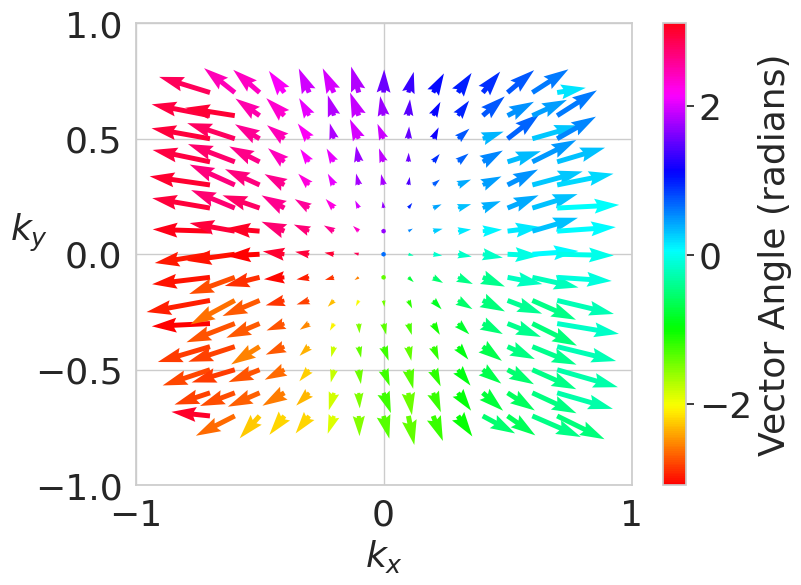

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_quiver_from_csv(file_path):
    # Load CSV file
    df = pd.read_csv(file_path)
    
    # Extract values
    k_x = df['k_x'].values
    k_y = df['k_y'].values
    final_pos_x = df['final_pos_x'].values
    final_pos_y = df['final_pos_y'].values
    
    # Compute vectors (from origin to final positions)
    u = final_pos_x  # x-component of vector
    v = final_pos_y  # y-component of vector
    
    # Compute angle of the vector (in degrees)
    angles = np.arctan2(v, u)
    
    # Create colormap based on angle
    norm = plt.Normalize(angles.min(), angles.max())
    colors = plt.cm.hsv(norm(angles))
    
    # Create the plot
    sns.set(style="whitegrid")
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Quiver plot with color
    q = ax.quiver(k_x, k_y, u, v, color=colors, angles='xy', scale_units='xy', scale=6, width=0.01)
    
    # Create colorbar
    sm = plt.cm.ScalarMappable(cmap='hsv', norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Vector Angle (radians)', fontsize=26)
    
    # Labels and title with increased size
    ax.set_xlabel('$k_x$', fontsize=26)
    # ax.set_xticklabels(ticks=[''], fontsize=18)
    # ax.set_xticks(fontsize=18)
    ax.set_ylabel('$k_y$', fontsize=26, rotation=0)
    # ax.set_title('Velocity direction', fontsize=25)
    ax.set_xlim([-1.0, 1.0])
    ax.set_ylim([-1.0, 1.0])
    plt.xticks([-1, 0, 1], fontsize=26)
    plt.yticks([-1, -0.5, 0, 0.5, 1], fontsize=26)
    cbar.ax.tick_params(labelsize=26) 

    # Show plot
    # plt.savefig('fig/hex_4legs_velocity_direction.png', bbox_inches='tight')
    plt.show()

# Example usage (replace 'data.csv' with your actual file path)
plot_quiver_from_csv('data_save/vary_gain_hex.csv')


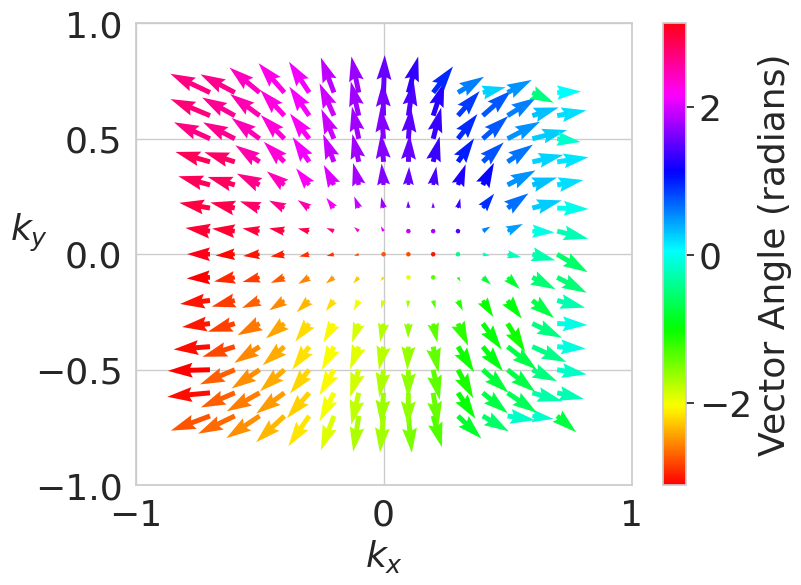

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_quiver_from_csv(file_path):
    # Load CSV file
    df = pd.read_csv(file_path)
    
    # Extract values
    k_x = df['k_x'].values
    k_y = df['k_y'].values
    final_pos_x = df['final_pos_x'].values
    final_pos_y = df['final_pos_y'].values
    
    # Compute vectors (from origin to final positions)
    u = final_pos_x  # x-component of vector
    v = final_pos_y  # y-component of vector
    
    # Compute angle of the vector (in degrees)
    angles = np.arctan2(v, u)
    
    # Create colormap based on angle
    norm = plt.Normalize(angles.min(), angles.max())
    colors = plt.cm.hsv(norm(angles))
    
    # Create the plot
    sns.set(style="whitegrid")
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Quiver plot with color
    q = ax.quiver(k_x, k_y, u, v, color=colors, angles='xy', scale_units='xy', scale=6, width=0.01)
    
    # Create colorbar
    sm = plt.cm.ScalarMappable(cmap='hsv', norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Vector Angle (radians)', fontsize=26)
    
    # Labels and title with increased size
    ax.set_xlabel('$k_x$', fontsize=26)
    # ax.set_xticklabels(ticks=[''], fontsize=18)
    # ax.set_xticks(fontsize=18)
    ax.set_ylabel('$k_y$', fontsize=26, rotation=0)
    # ax.set_title('Velocity direction', fontsize=25)
    ax.set_xlim([-1.0, 1.0])
    ax.set_ylim([-1.0, 1.0])
    plt.xticks([-1, 0, 1], fontsize=26)
    plt.yticks([-1, -0.5, 0, 0.5, 1], fontsize=26)
    cbar.ax.tick_params(labelsize=26) 

    # Show plot
    # plt.savefig('fig/quad_velocity_direction.png', bbox_inches='tight')
    plt.show()

# Example usage (replace 'data.csv' with your actual file path)
plot_quiver_from_csv('data_save/vary_gain_quad.csv')


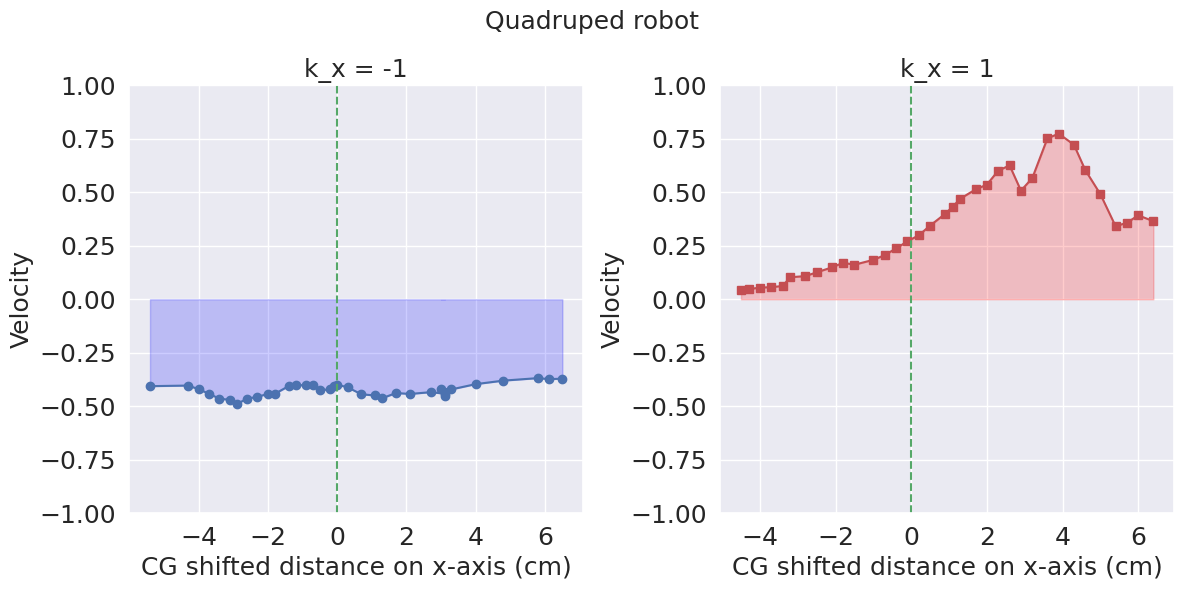

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data from CSV file
data = pd.read_csv('data_save/vary_cg_quad.csv')  # Updated file path

# Adjust mass shift values
adjusted_mass_shift = data['mass_shift']

# Calculate the velocity with direction
# Using the sign of final_pos_x to determine the direction
velocity = np.sign(data['final_pos_x']) * np.sqrt(data['final_pos_x']**2 + data['final_pos_y']**2)

# Filter data based on k_x
negative_kx_data = data[data['k_x'] < 0]
positive_kx_data = data[data['k_x'] > 0]

# Adjusted mass shift for filtered data
adjusted_mass_shift_neg_kx = negative_kx_data['mass_shift']*100 
adjusted_mass_shift_pos_kx = positive_kx_data['mass_shift']*100

# Corresponding velocities
velocity_neg_kx = np.sign(negative_kx_data['final_pos_x']) * np.sqrt(negative_kx_data['final_pos_x']**2 + negative_kx_data['final_pos_y']**2)
velocity_pos_kx = np.sign(positive_kx_data['final_pos_x']) * np.sqrt(positive_kx_data['final_pos_x']**2 + positive_kx_data['final_pos_y']**2)

# Plotting
plt.figure(figsize=(12, 6))

# Subplot 1: Mass Shift vs Velocity when k_x is negative
plt.subplot(1, 2, 1)
plt.plot(adjusted_mass_shift_neg_kx, velocity_neg_kx, marker='o', linestyle='-', color='b')
plt.fill_between(adjusted_mass_shift_neg_kx, velocity_neg_kx, color='blue', alpha=0.2)  # Fill color
plt.axvline(x=0, color='g', linestyle='--')  # Vertical line at x = 0 (since adjusted)
plt.xlabel('CG shifted distance on x-axis (cm)', fontsize=18)
plt.ylabel('Velocity', fontsize=18)
plt.title('k_x = -1', fontsize=18)
plt.ylim(-1.0, 1.0)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)

# Subplot 2: Mass Shift vs Velocity when k_x is positive
plt.subplot(1, 2, 2)
plt.plot(adjusted_mass_shift_pos_kx, velocity_pos_kx, marker='s', linestyle='-', color='r')
plt.fill_between(adjusted_mass_shift_pos_kx, velocity_pos_kx, color='red', alpha=0.2)  # Fill color
plt.axvline(x=0, color='g', linestyle='--')  # Vertical line at x = 0 (since adjusted)
plt.xlabel('CG shifted distance on x-axis (cm)', fontsize=18)
plt.ylabel('Velocity', fontsize=18)
plt.title('k_x = 1', fontsize=18)
plt.suptitle('Quadruped robot', fontsize=18)
plt.ylim(-1.0, 1.0)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)

plt.tight_layout()
plt.savefig('fig/velocity_vs_mass_shift.png', bbox_inches='tight')
plt.show()


In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

def select_and_plot_polar_walk_traj(data, num_trajectories=10, seed=42, title_name="Quadruped robot"):
    random.seed(seed)  # Set seed for reproducibility
    # Convert Cartesian coordinates (posX, posY) to polar coordinates (r, theta)
    data['r'] = np.sqrt(data['posX']**2 + data['posY']**2)  # Radius
    data['theta'] = np.arctan2(data['posY'], data['posX'])  # Angle in radians

    # Create a polar plot
    plt.figure(figsize=(4, 4))
    ax = plt.subplot(111, projection='polar')  # Set up polar projection

    # Group by (kx, ky) and plot each trajectory
    grouped = data.groupby(["kx", "ky"])
    group_keys = list(grouped.groups.keys())

    if len(group_keys) <= num_trajectories:
        selected_groups = group_keys
    else:
        selected_groups = random.sample(group_keys, num_trajectories)

    for kx, ky in selected_groups:
        group = grouped.get_group((kx, ky))
        ax.scatter(group['theta'], group['r'], marker='.', linestyle='-', zorder=0,
                    s=20, label=f"kx={kx}, ky={ky}")

    # Add labels and title
    ax.set_title(title_name, va='top', pad=50, fontsize=18)  # Increase `pad` to move the title up
    ax.grid(True,  zorder=1)
    ax.tick_params(axis='x', labelsize=18, pad=5)  # Adjust font size of angular ticks

    # Add a legend
    # plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

    plt.show()

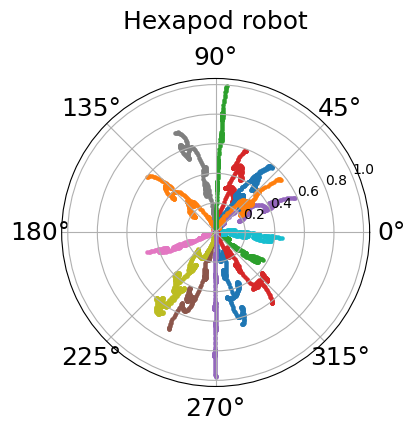

In [155]:
num_trajectories=15

# Load the CSV file
data = pd.read_csv("data_save/walk_traject_6legs.csv")  # Update with your actual file path
select_and_plot_polar_walk_traj(data, num_trajectories=15, seed=12, title_name="Hexapod robot")


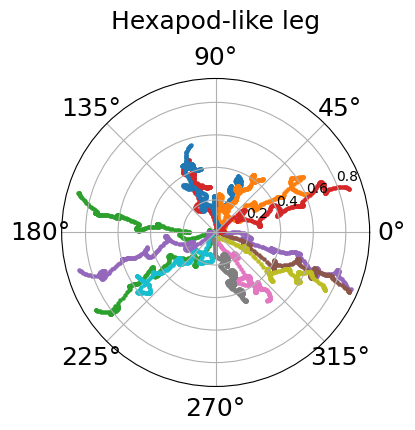

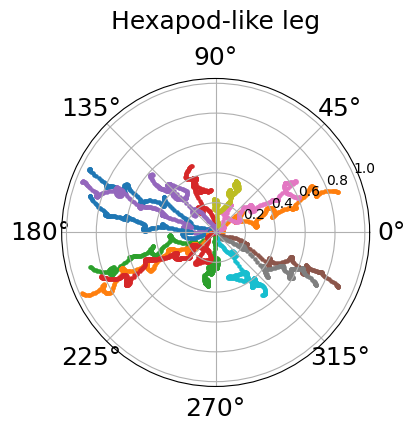

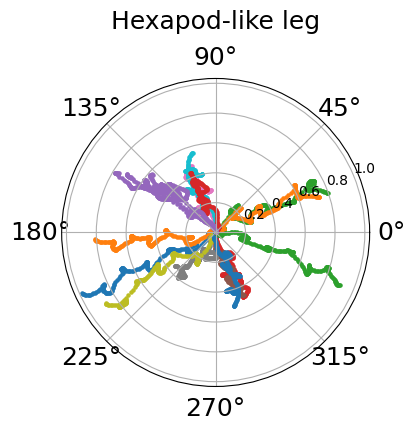

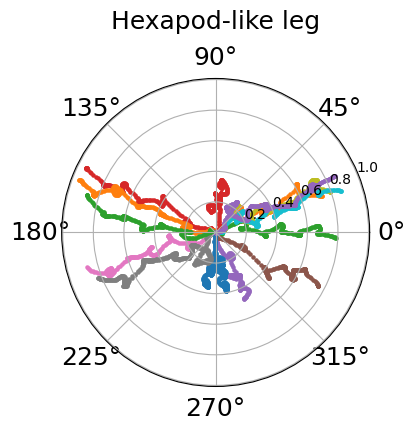

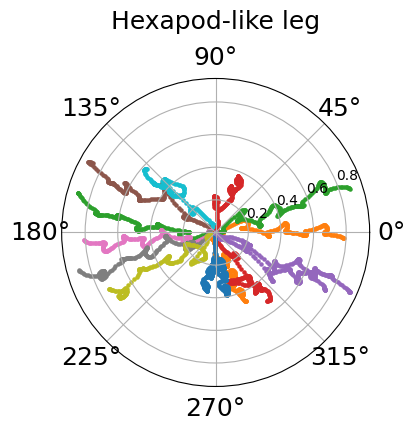

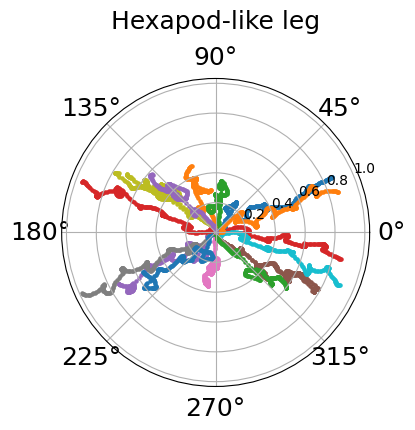

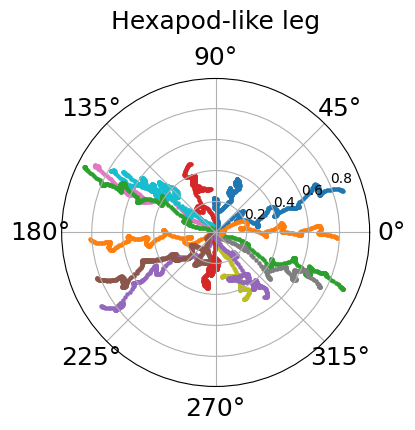

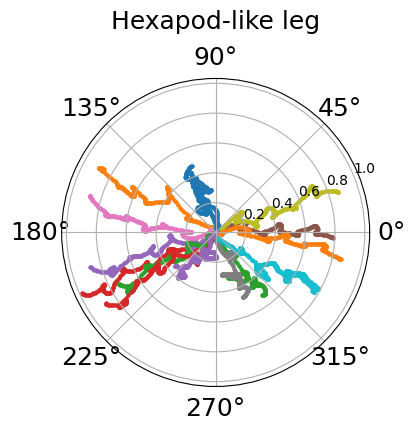

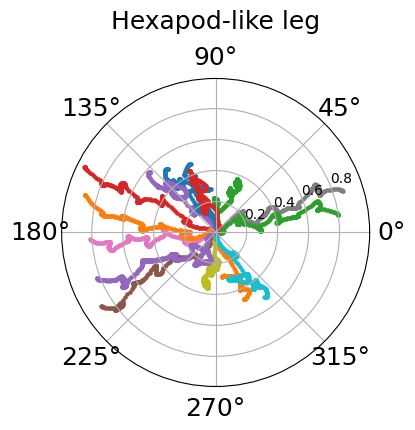

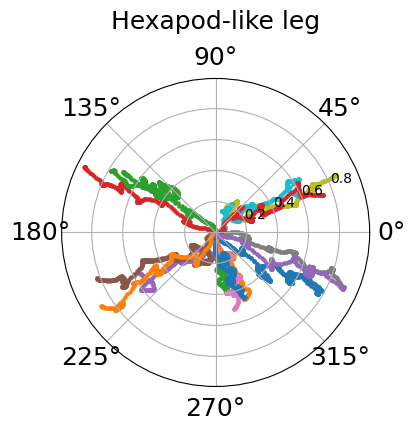

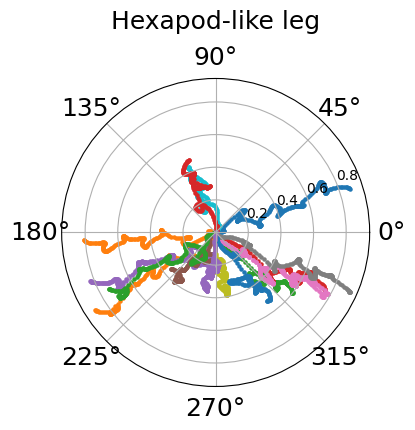

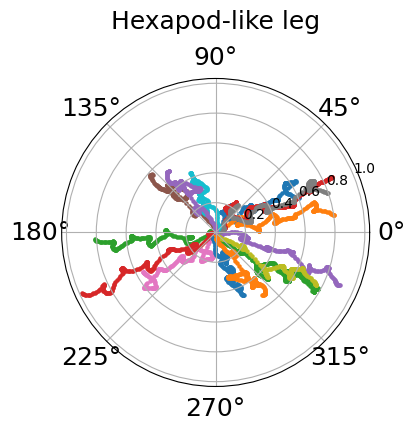

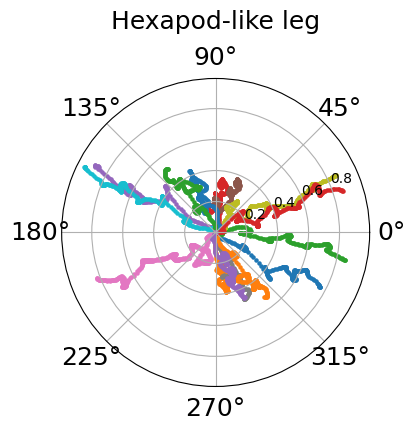

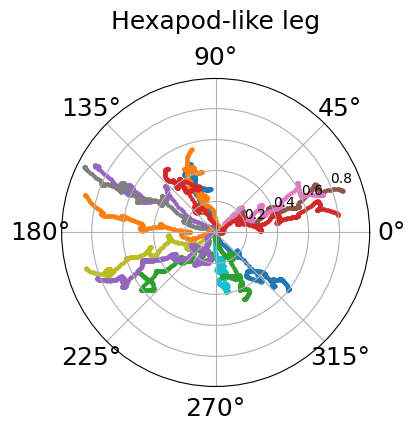

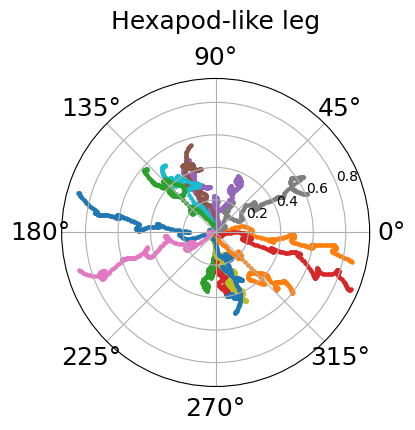

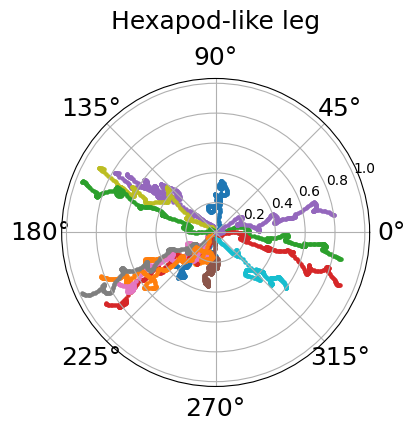

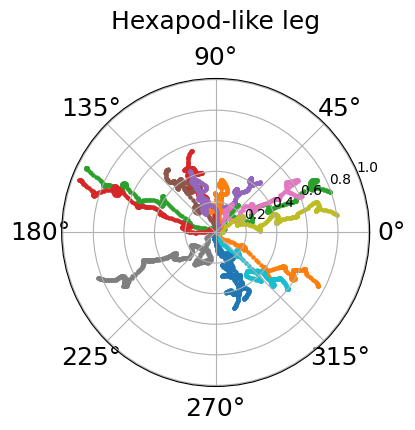

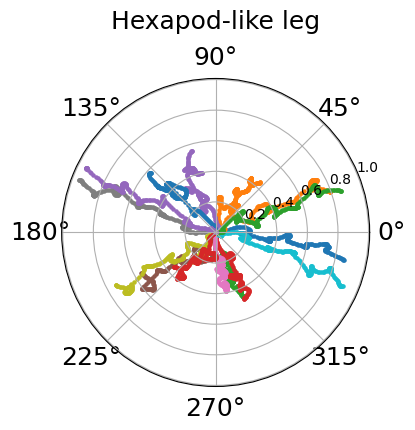

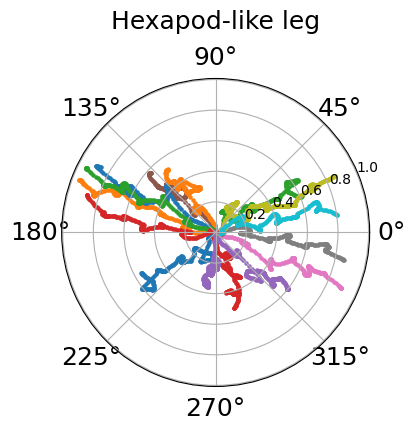

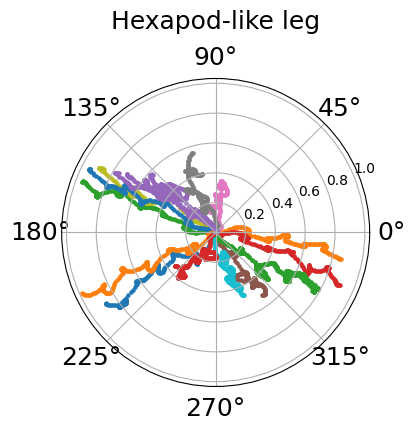

In [167]:
num_trajectories=15

# Load the CSV file
data = pd.read_csv("data_save/walk_traject_hex.csv")  # Update with your actual file path
for i in range(20):
    select_and_plot_polar_walk_traj(data, num_trajectories=15, seed=i, title_name="Hexapod-like leg")


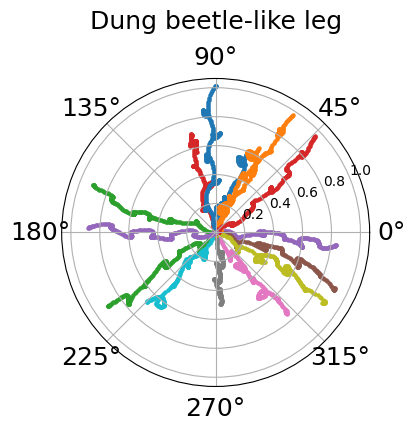

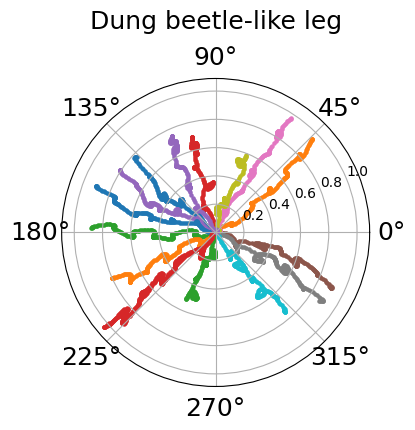

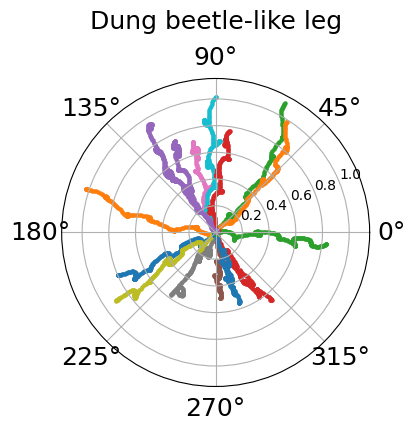

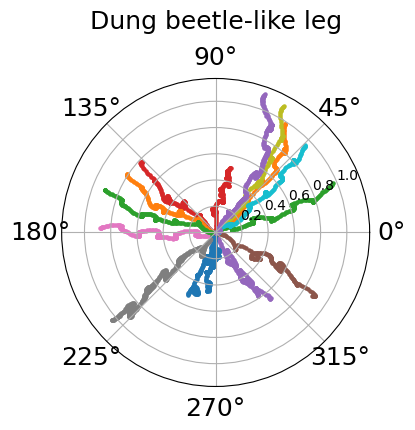

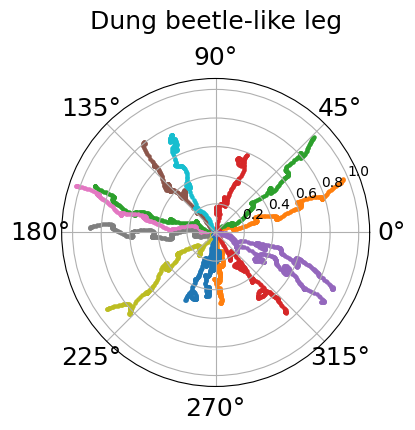

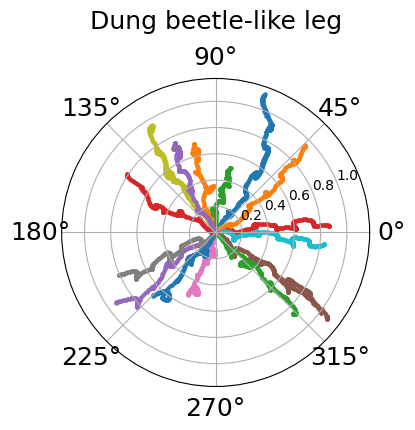

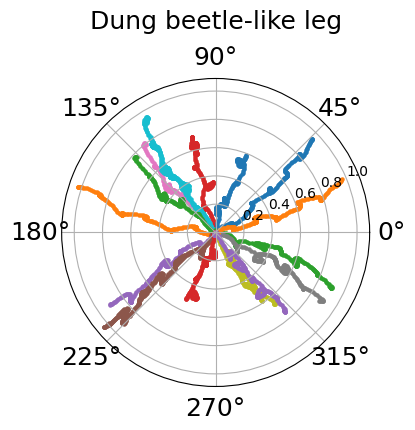

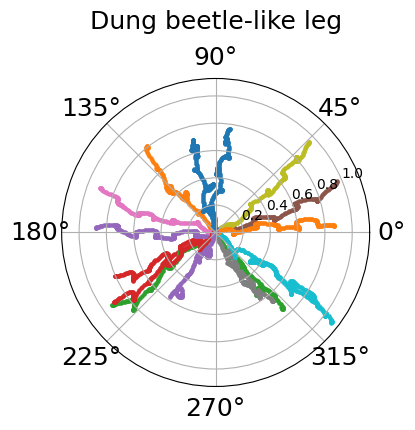

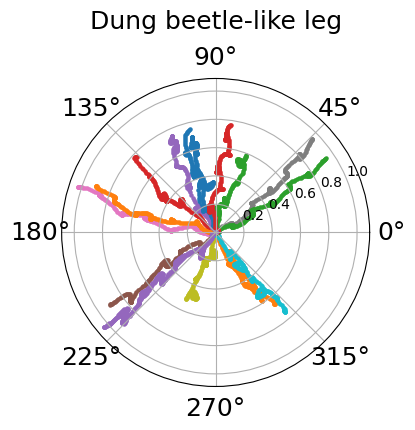

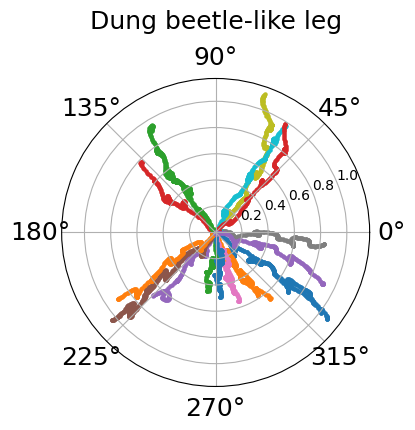

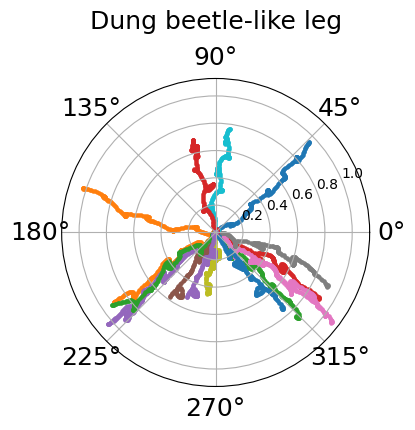

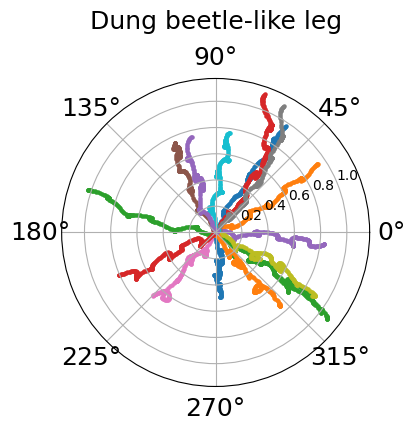

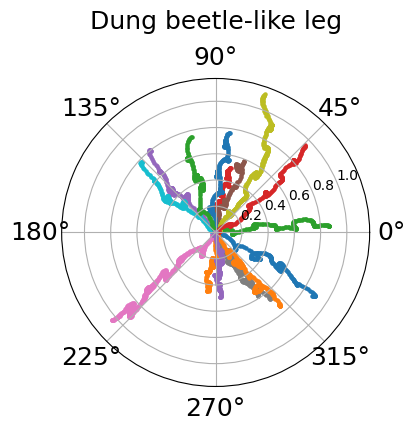

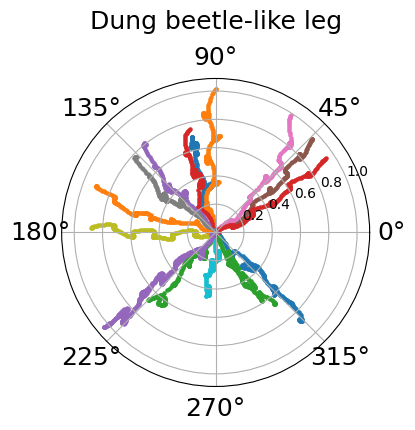

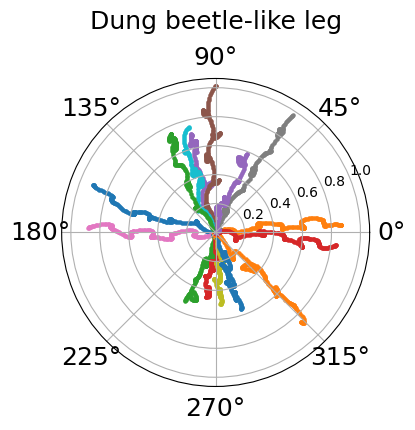

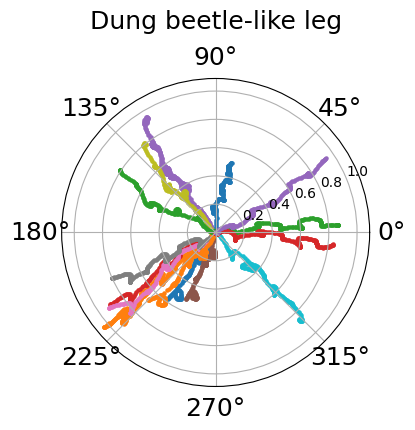

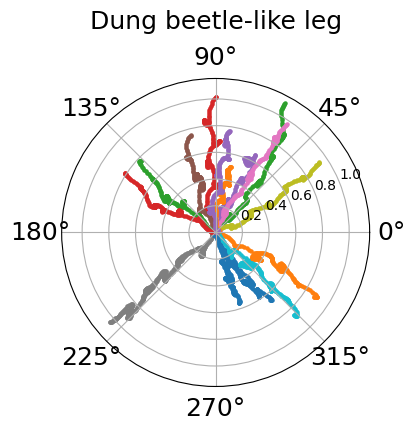

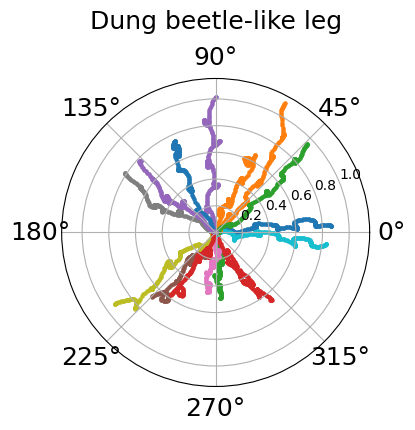

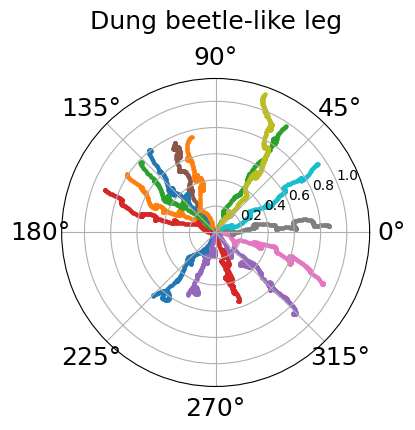

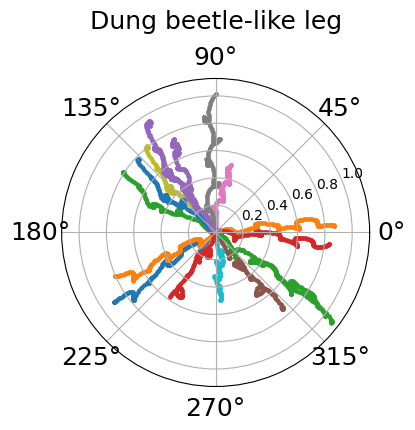

In [168]:
num_trajectories=15

# Load the CSV file
data = pd.read_csv("data_save/walk_traject_db.csv")  # Update with your actual file path
for i in range(20):
    select_and_plot_polar_walk_traj(data, num_trajectories=15, seed=i, title_name="Dung beetle-like leg")


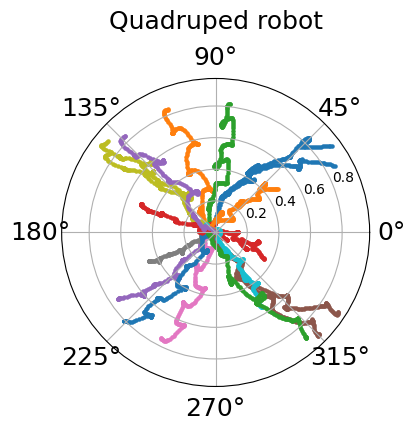

In [142]:
num_trajectories=15

# Load the CSV file
data = pd.read_csv("data_save/walk_traject_quad.csv")  # Update with your actual file path
select_and_plot_polar_walk_traj(data, num_trajectories=15, seed=5, title_name="Quadruped robot")

      Time (s)   kx   ky   posX   posY   posZ         r     theta
4200    128.42  0.5  0.5  0.000  0.000  0.227  0.000000  0.000000
4201    128.44  0.5  0.5  0.000 -0.001  0.221  0.001000 -1.570796
4202    128.46  0.5  0.5 -0.002 -0.003  0.215  0.003606 -2.158799
4203    128.48  0.5  0.5 -0.006 -0.003  0.208  0.006708 -2.677945
4204    128.50  0.5  0.5 -0.008 -0.002  0.200  0.008246 -2.896614
...        ...  ...  ...    ...    ...    ...       ...       ...
8795    264.76  0.5  0.5  0.690  0.545  0.188  0.879275  0.668524
8796    264.78  0.5  0.5  0.702  0.546  0.187  0.889337  0.661043
8797    264.80  0.5  0.5  0.714  0.546  0.186  0.898839  0.652847
8798    264.82  0.5  0.5  0.726  0.547  0.184  0.909002  0.645701
8799    264.84  0.5  0.5  0.738  0.547  0.181  0.918615  0.637840

[400 rows x 8 columns]


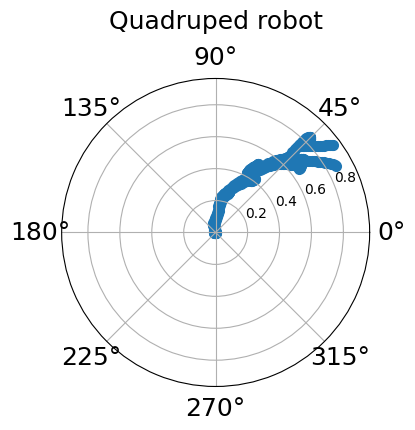

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
data = pd.read_csv("data_save/walk_traject_quad.csv")  # Update with your actual file path

# filter data
data = data[(data['kx'] > 0.45) & (data['ky'] > 0.45)]

# Convert Cartesian coordinates (posX, posY) to polar coordinates (r, theta)
data['r'] = np.sqrt(data['posX']**2 + data['posY']**2)  # Radius
data['theta'] = np.arctan2(data['posY'], data['posX'])  # Angle in radians

print(data)

# Create a polar plot
plt.figure(figsize=(4, 4))
ax = plt.subplot(111, projection='polar')  # Set up polar projection

# Group by (kx, ky) and plot each trajectory
for (kx, ky), group in data.groupby(["kx", "ky"]):
    ax.scatter(group['theta'], group['r'], marker='o', linestyle='-',  zorder=0 ,
            linewidth=2, label=f"kx={kx}, ky={ky}")

# Add labels and title
ax.set_title("Quadruped robot", va='top', pad=50, fontsize=18)  # Increase `pad` to move the title up
ax.grid(True,  zorder=1)
ax.tick_params(axis='x', labelsize=18, pad=5)  # Adjust font size of angular ticks

# Add a legend
# plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

plt.show()